# Measure analysis

##### Imports and params

In [2]:
from __future__ import annotations

import pandas as pd

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [3]:
plt.rcParams.update({
"figure.figsize": (18, 10),
"axes.grid": True,
"grid.linestyle": ":",
"grid.alpha": 0.5,
"axes.titlesize": 14,
"axes.labelsize": 12,
"legend.fontsize": 10,
})

In [4]:
MORPHO_RESULTS = Path("/home/loai/Documents/code/RSMLExtraction/RSA_reconstruction/Method/ChronoRoot/GLOBAL_MORPHOLOGY.csv").expanduser()
DYNAMIC_RESULTS = Path("/home/loai/Documents/code/RSMLExtraction/RSA_reconstruction/Method/ChronoRoot/GLOBAL_DYNAMICS.csv").expanduser()
GT_MORPHO_RESULTS = Path("/home/loai/Documents/code/RSMLExtraction/RSA_reconstruction/Method/ChronoRoot/Ground_truth_root.csv").expanduser()
PATH_2_LOGS = Path("/home/loai/Documents/code/RSMLExtraction/RSA_reconstruction/Method/ChronoRoot/log_chronoRoot.csv").expanduser()

## Loading database

In [5]:
df_plant_morpho = pd.read_csv(MORPHO_RESULTS)

df_plant_morpho = df_plant_morpho.drop(columns=["FileName"])

# order by box_name, img_num, plant_num, Time elapsed (hours)
df_plant_morpho = df_plant_morpho.sort_values(by=["box_name", "img_num", "plant_num", "Time elapsed (hours)"])

# rename columns: loss to loss, model to model
df_plant_morpho = df_plant_morpho.rename(columns={"loss_name": "loss", "model_name": "model"})

df_plant_morpho.head()

,box_name,loss,epoch,img_num,plant_num,TimeStep,MainRootLength,LateralRootsLength,NumberOfLateralRoots,TotalLength,TotalOrganCount,ConvexHullArea,RootDensity,Time elapsed (hours),Acquisition Time
3459,rpi14_2020-01-08_17-25,CLDICE,5,1,2,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
11504,rpi14_2020-01-08_17-25,CLDICE,125,1,2,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
22504,rpi14_2020-01-08_17-25,CLDICE,130,1,2,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
34072,rpi14_2020-01-08_17-25,CLDICE,70,1,2,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
45431,rpi14_2020-01-08_17-25,CLDICE,155,1,2,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0


In [6]:
time_step_hours = df_plant_morpho['Time elapsed (hours)'].diff().loc[df_plant_morpho['Time elapsed (hours)'].diff() > 0].median()
print(f"Intervalle détecté entre les images : {time_step_hours} heures (soit {time_step_hours*60} min)")

Intervalle détecté entre les images : 0.25 heures (soit 15.0 min)


In [7]:
df_plant_dynamics = pd.read_csv(DYNAMIC_RESULTS)

df_plant_dynamics = df_plant_dynamics.drop(columns=["newDay"])

df_plant_dynamics['Time elapsed (hours)'] = df_plant_dynamics['Time'] * 4 * time_step_hours

all_messurements = [col for col in df_plant_dynamics.columns if col not in ['box_name', 'img_num', 'plant_num', 'Time']]

for col in all_messurements:
    if col.endswith('Grad'):
        #float
        df_plant_dynamics[col] = df_plant_dynamics[col] * (4.0 * time_step_hours)
    if col.endswith('Accel'):
        df_plant_dynamics[col] = (df_plant_dynamics[col] * (4.0 * time_step_hours) **2)

# order by box_name, img_num, plant_num, time
df_plant_dynamics = df_plant_dynamics.sort_values(by=["box_name", "img_num", "plant_num", "Time"])

cols = ['box_name', 'img_num', 'plant_num', 'Time elapsed (hours)']
cols += [c for c in df_plant_dynamics.columns if c not in cols]
df_plant_dynamics = df_plant_dynamics[cols]

# rename columns: loss to loss, model to model
df_plant_dynamics = df_plant_dynamics.rename(columns={"loss_name": "loss", "model_name": "model"})

df_plant_dynamics.head()

,box_name,img_num,plant_num,Time elapsed (hours),loss,epoch,Time,mainRootLength,lateralRootsLength,totalRootsLength,...,totalRootsGrad,mainRootAccel,lateralRootsAccel,totalRootsAccel,NumberOfLateralRoots,ConvexHullArea,RootDensity,mainOverTotal,lateralRootDensity,lateralRootContDensity
864,rpi14_2020-01-08_17-25,1,2,0.0,CLDICE,5,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0
2874,rpi14_2020-01-08_17-25,1,2,0.0,CLDICE,125,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0
5621,rpi14_2020-01-08_17-25,1,2,0.0,CLDICE,130,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0
8510,rpi14_2020-01-08_17-25,1,2,0.0,CLDICE,70,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0
11346,rpi14_2020-01-08_17-25,1,2,0.0,CLDICE,155,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0


In [8]:
df_ground_truth = pd.read_csv(GT_MORPHO_RESULTS)
df_ground_truth = df_ground_truth.drop(columns=["FileName"])

df_ground_truth = df_ground_truth.sort_values(by=["box_name", "img_num", "plant_num", "Time elapsed (hours)"])

# rename columns in df_ground_truth to match df_plant_morpho
df_ground_truth = df_ground_truth.rename(columns={
    "PrimaryRootLength": "MainRootLength",
    "LateralRootLength": "LateralRootsLength",
    "TotalRootLength": "TotalLength",
    "NumberOfLateralRoots": "NumberOfLateralRoots",
    "mainRootGrad": "mainRootGrad",
    "mainRootAccel": "mainRootAccel",
    "lateralRootsGrad": "lateralRootsGrad",
    "lateralRootsAccel": "lateralRootsAccel",
    "totalRootsGrad": "totalRootsGrad",
    "totalRootsAccel": "totalRootsAccel",
    "NumberOfOrgans": "TotalOrganCount",
    "Convex_Area_Hull": "ConvexHullArea",
    "RootDensity": "RootDensity",
})

df_ground_truth.head()

,box_name,img_num,plant_num,TimeStep,TotalLength,LateralRootsLength,NumberOfLateralRoots,mainRootGrad,mainRootAccel,lateralRootsGrad,lateralRootsAccel,totalRootsGrad,totalRootsAccel,TotalOrganCount,ConvexHullArea,RootDensity,Time elapsed (hours),Acquisition Time,MainRootLength
9596,rpi14_2020-01-08_17-25,1,1,429,1.793137,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1,0.0576,31.130852,107.25,11.15,1.793137
9597,rpi14_2020-01-08_17-25,1,1,430,1.889706,0.0,0.0,0.386274,NaN,0.0,NaN,0.386274,NaN,1,0.0952,19.849849,107.50,11.30,1.889706
9598,rpi14_2020-01-08_17-25,1,1,431,1.889706,0.0,0.0,0.000000,-1.545097,0.0,0.0,0.000000,-1.545097,1,0.0960,19.684434,107.75,11.45,1.889706
9599,rpi14_2020-01-08_17-25,1,1,432,1.833137,0.0,0.0,-0.226274,-0.905097,0.0,0.0,-0.226274,-0.905097,1,0.0600,30.552285,108.00,12.00,1.833137
9600,rpi14_2020-01-08_17-25,1,1,433,1.833137,0.0,0.0,0.000000,0.905097,0.0,0.0,0.000000,0.905097,1,0.0592,30.965153,108.25,12.15,1.833137


In [9]:
df_logs_tb = pd.read_csv(PATH_2_LOGS)

cols_2_drop = ['l2', 'runtime', 'run_name', '_step', '_runtime', '_timestamp']

df_logs_tb = df_logs_tb.drop(columns=cols_2_drop)

# loss col values to capital letters 
df_logs_tb['loss'] = df_logs_tb['loss'].str.upper()

df_logs_tb['loss'] = df_logs_tb['loss'].replace('CROSS_ENTROPY', 'BCE')

df_logs_tb

,val/b1_pred,val/hausdorff_max,val/iou,val/precision,val/normalized_mutual_information,val/f_4_score,val/pixel_accuracy,val/dice_gpu,val/betti0_jaccard_ratio,val/mean_iou,...,val/ASCD,val/betti0_relative_error,val/betti0_variation_index,val/betti1_jaccard_ratio,epoch,val/f_2_score,val/precision_gpu,val/recall_gpu,model,loss
0,22.745455,56.087179,0.092679,0.100044,0.125598,0.459013,0.964857,0.962089,0.001927,0.528698,...,16.520192,712.986088,0.996172,0.261276,1,0.279267,0.093935,0.704786,UNet,DICE
1,0.545455,60.892417,0.003781,0.041300,0.003107,0.005018,0.993870,0.993790,0.037607,0.498826,...,19.989314,69.459610,0.944005,0.029829,2,0.005542,0.091548,0.481256,UNet,DICE
2,2615.600000,80.139733,0.007810,0.007811,0.013081,0.110863,0.333813,0.337983,0.004073,0.169056,...,28.669586,278.685966,0.991892,0.025519,3,0.037161,0.021877,0.481075,UNet,DICE
3,85.163636,56.769239,0.335946,0.479344,0.360629,0.568811,0.995057,0.994804,0.007480,0.665492,...,5.551066,163.579408,0.985189,0.388940,4,0.534008,0.014508,0.555942,UNet,DICE
4,5384.163636,56.667615,0.036843,0.049539,0.031545,0.139918,0.931543,0.926478,0.000464,0.484134,...,14.099082,2422.370585,0.999072,0.044579,5,0.094821,0.016232,0.514277,UNet,DICE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,23.927273,41.421880,0.590325,0.655248,0.614620,0.844750,0.997097,0.997126,0.198218,0.793700,...,0.867220,5.692489,0.683135,0.373565,196,0.806767,0.540965,0.816618,ResUNetDS,CLDICE
2996,22.909091,38.993474,0.593101,0.665183,0.615554,0.836677,0.997162,0.997182,0.201406,0.795121,...,0.686706,5.691450,0.677184,0.348238,197,0.802691,0.541572,0.816697,ResUNetDS,CLDICE
2997,22.709091,44.822973,0.586206,0.649856,0.612211,0.846334,0.997119,0.997139,0.173458,0.791652,...,0.908569,6.422424,0.714819,0.370728,198,0.805901,0.542177,0.816779,ResUNetDS,CLDICE
2998,21.236364,38.111341,0.601553,0.695479,0.618902,0.812682,0.997324,0.997359,0.201166,0.799429,...,0.567289,5.947742,0.679215,0.326848,199,0.790000,0.542813,0.816764,ResUNetDS,CLDICE


## Prepare diff datasets

### Merge Morpho and dync

In [10]:
merge_keys = ["box_name", "img_num", "plant_num", "Time elapsed (hours)", "epoch", "loss"]

df_morpho_dync = pd.merge(
    df_plant_morpho,
    df_plant_dynamics,
    on=merge_keys,
    how="outer",
    suffixes=('_morpho', '_dync')
)

/home/loai/miniforge3/envs/utils/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


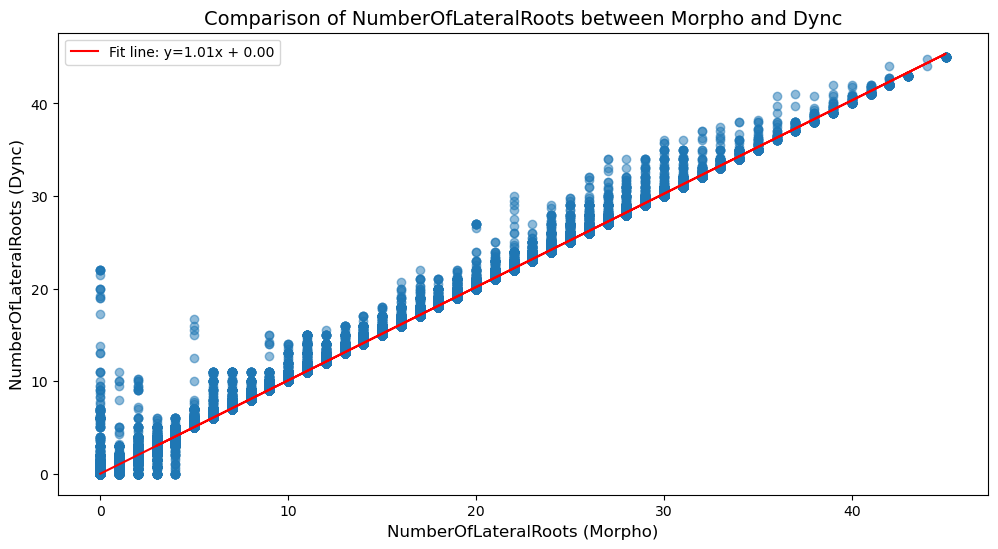

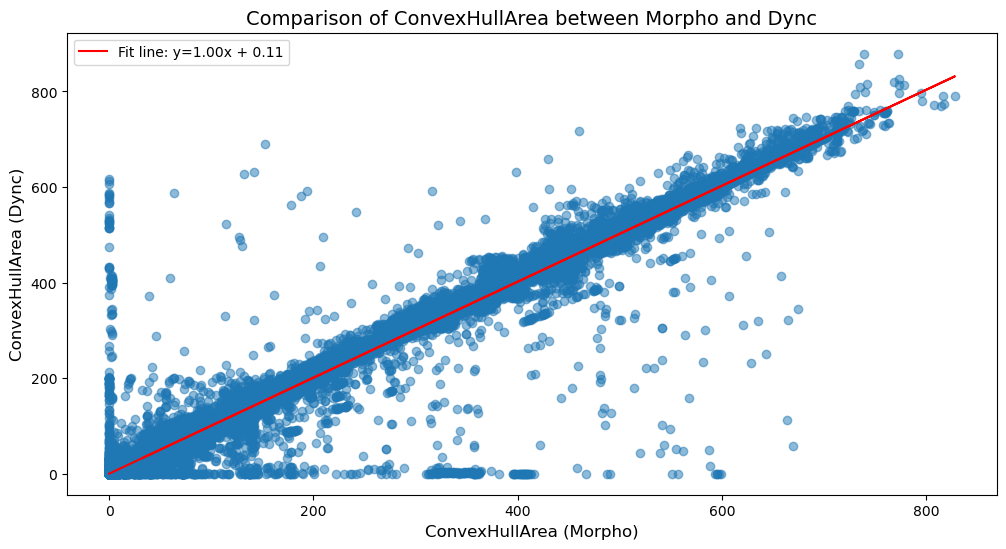

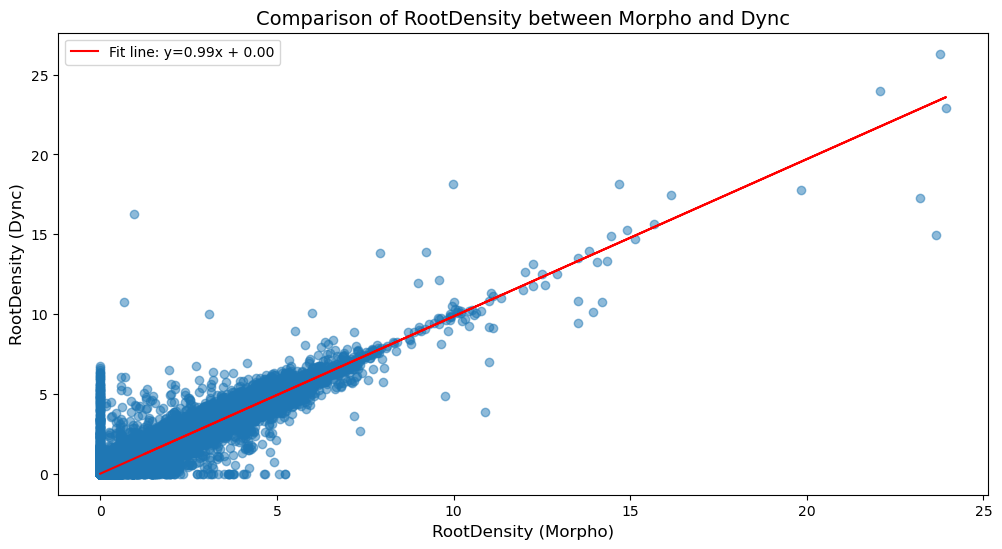

In [11]:
# plot differences bewtween _morpho and _dync for all concerned columns
for col in df_morpho_dync.columns:
    if col.endswith('_morpho'):
        base_col = col[:-7]
        dync_col = base_col + '_dync'
        if dync_col in df_morpho_dync.columns:
            plt.figure(figsize=(12, 6))
            plt.scatter(df_morpho_dync[base_col + '_morpho'], df_morpho_dync[dync_col], alpha=0.5)
            # plot regression line + statistics
            x = df_morpho_dync[base_col + '_morpho']
            y = df_morpho_dync[dync_col]
            # remove rows with NaN values in x or y
            mask = ~x.isna() & ~y.isna()
            x = x[mask]
            y = y[mask]
            if len(x) > 1 and len(y) > 1:
                coeffs = np.polyfit(x, y, 1)
                poly_eqn = np.poly1d(coeffs)
                plt.plot(x, poly_eqn(x), color='red', label=f'Fit line: y={coeffs[0]:.2f}x + {coeffs[1]:.2f}')
                plt.legend()
            plt.xlabel(f'{base_col} (Morpho)')
            plt.ylabel(f'{base_col} (Dync)')
            plt.title(f'Comparison of {base_col} between Morpho and Dync')
            plt.grid()
            plt.show()

In [12]:
# drop _dync columns and rename _morpho columns to remove _morpho suffix
df_morpho_dync = df_morpho_dync.drop(columns=[col for col in df_morpho_dync.columns if col.endswith('_dync')])
df_morpho_dync = df_morpho_dync.rename(columns={col: col[:-7] for col in df_morpho_dync.columns if col.endswith('_morpho')})

In [13]:
# print number of rows in df_morpho_dync, df_plant_morpho, df_plant_dynamics
print(f"Number of rows in df_morpho_dync: {len(df_morpho_dync)}")
print(f"Number of rows in df_plant_morpho: {len(df_plant_morpho)}")
print(f"Number of rows in df_plant_dynamics: {len(df_plant_dynamics)}")

Number of rows in df_morpho_dync: 4898833
Number of rows in df_plant_morpho: 4895769
Number of rows in df_plant_dynamics: 1222861


### Morpho

In [14]:
merge_keys = ["box_name", "img_num", "plant_num", "Time elapsed (hours)", "Acquisition Time"]
df_merged = pd.merge(
    df_morpho_dync, 
    df_ground_truth, 
    on=merge_keys, 
    how="inner", 
    suffixes=('_pred', '_gt')
)

measurement_cols = [col for col in df_merged.columns if col.endswith('_pred') or col.endswith('_gt')]
df_merged = df_merged[merge_keys + measurement_cols + ["loss", "epoch"]]

df_merged.head()

,box_name,img_num,plant_num,Time elapsed (hours),Acquisition Time,TimeStep_pred,MainRootLength_pred,LateralRootsLength_pred,NumberOfLateralRoots_pred,TotalLength_pred,...,lateralRootsGrad_gt,lateralRootsAccel_gt,totalRootsGrad_gt,totalRootsAccel_gt,TotalOrganCount_gt,ConvexHullArea_gt,RootDensity_gt,MainRootLength_gt,loss,epoch
0,rpi14_2020-01-08_17-25,1,2,122.25,2.15,489.0,1.778148,0.0,0.0,1.778148,...,NaN,NaN,NaN,NaN,1,0.0088,42.012003,0.369706,CLDICE,5
1,rpi14_2020-01-08_17-25,1,2,122.25,2.15,489.0,5.041056,0.0,0.0,5.041056,...,NaN,NaN,NaN,NaN,1,0.0088,42.012003,0.369706,BCE,10
2,rpi14_2020-01-08_17-25,1,2,122.25,2.15,489.0,4.994956,0.0,0.0,4.994956,...,NaN,NaN,NaN,NaN,1,0.0088,42.012003,0.369706,CLDICE,10
3,rpi14_2020-01-08_17-25,1,2,122.25,2.15,489.0,5.111143,0.0,0.0,5.111143,...,NaN,NaN,NaN,NaN,1,0.0088,42.012003,0.369706,DICE,10
4,rpi14_2020-01-08_17-25,1,2,122.25,2.15,489.0,4.341884,0.0,0.0,4.341884,...,NaN,NaN,NaN,NaN,1,0.0088,42.012003,0.369706,CLDICE,15


In [17]:
pred_cols = [c for c in df_merged.columns if c.endswith('_pred')]
base_metrics = [c.replace('_pred', '') for c in pred_cols]

valid_metrics = [m for m in base_metrics if f"{m}_gt" in df_merged.columns]

if 'Time elapsed (hours)_pred' in df_merged.columns:
    df_merged = df_merged.rename(columns={'Time elapsed (hours)_pred': 'Time elapsed (hours)'})

potential_meta_cols = ["box_name", "img_num", "plant_num", "epoch", "loss", "Time elapsed (hours)", "Acquisition Time"]
meta_cols = [c for c in potential_meta_cols if c in df_merged.columns]

df_diff_merged = df_merged[meta_cols].copy()

for metric in valid_metrics:
    df_diff_merged[f"{metric}_signed_err"] = df_merged[f"{metric}_pred"] - df_merged[f"{metric}_gt"]
        
    df_diff_merged[f"{metric}_abs_err"] = df_diff_merged[f"{metric}_signed_err"].abs()
    
    floatgt = abs(df_merged[f"{metric}_gt"].astype(float))
    df_diff_merged[f'{metric}_rel_err'] = df_diff_merged[f"{metric}_abs_err"] / (floatgt + 1e-9)
    
    floatpred = abs(df_merged[f"{metric}_pred"].astype(float))
    df_diff_merged[f'{metric}_smape_err'] = 2 * df_diff_merged[f"{metric}_abs_err"] / (floatgt + floatpred + 1e-9)
    
    df_diff_merged[f'{metric}_log_acc_ratio'] = ((df_merged[f"{metric}_pred"].astype(float) + 1e-9).apply(lambda x: max(x, 1e-9)).apply(lambda x: np.log(x)) - (df_merged[f"{metric}_gt"].astype(float) + 1e-9).apply(lambda x: max(x, 1e-9)).apply(lambda x: np.log(x))).abs()
    
# drop TimeStep_pred and TimeStep_gt if they exist
df_diff_merged = df_diff_merged.drop(columns=[col for col in ['TimeStep_signed_err', 'TimeStep_abs_err', 'TimeStep_rel_err'] if col in df_diff_merged.columns])

#df_diff_merge.dropna(inplace=True)

df_diff_merged.head()

,box_name,img_num,plant_num,epoch,loss,Time elapsed (hours),Acquisition Time,TimeStep_smape_err,TimeStep_log_acc_ratio,MainRootLength_signed_err,...,lateralRootsAccel_signed_err,lateralRootsAccel_abs_err,lateralRootsAccel_rel_err,lateralRootsAccel_smape_err,lateralRootsAccel_log_acc_ratio,totalRootsAccel_signed_err,totalRootsAccel_abs_err,totalRootsAccel_rel_err,totalRootsAccel_smape_err,totalRootsAccel_log_acc_ratio
0,rpi14_2020-01-08_17-25,1,2,5,CLDICE,122.25,2.15,0.0,0.0,1.408442,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,rpi14_2020-01-08_17-25,1,2,10,BCE,122.25,2.15,0.0,0.0,4.671350,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,rpi14_2020-01-08_17-25,1,2,10,CLDICE,122.25,2.15,0.0,0.0,4.625250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,rpi14_2020-01-08_17-25,1,2,10,DICE,122.25,2.15,0.0,0.0,4.741437,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,rpi14_2020-01-08_17-25,1,2,15,CLDICE,122.25,2.15,0.0,0.0,3.972178,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Merge with logs

In [18]:
subset_keys = ['epoch', 'loss', 'model']


duplicates_mask = df_logs_tb.duplicated(subset=subset_keys, keep=False)
df_duplicates = df_logs_tb[duplicates_mask]

df_duplicates = df_duplicates.sort_values(by=subset_keys)

print(f"Nombre total de lignes dupliquées : {len(df_duplicates)}")
print("Aperçu des doublons :")
df_duplicates

Nombre total de lignes dupliquées : 0
Aperçu des doublons :


,val/b1_pred,val/hausdorff_max,val/iou,val/precision,val/normalized_mutual_information,val/f_4_score,val/pixel_accuracy,val/dice_gpu,val/betti0_jaccard_ratio,val/mean_iou,...,val/ASCD,val/betti0_relative_error,val/betti0_variation_index,val/betti1_jaccard_ratio,epoch,val/f_2_score,val/precision_gpu,val/recall_gpu,model,loss


In [19]:
df_diff_log = pd.merge(
    df_diff_merged,
    df_logs_tb, 
    on=['loss', 'epoch'], 
    how='left'
)

df_diff_log = df_diff_log
df_diff_log.head()

,box_name,img_num,plant_num,epoch,loss,Time elapsed (hours),Acquisition Time,TimeStep_smape_err,TimeStep_log_acc_ratio,MainRootLength_signed_err,...,val/f_3_score,val/specificity,val/ASCD,val/betti0_relative_error,val/betti0_variation_index,val/betti1_jaccard_ratio,val/f_2_score,val/precision_gpu,val/recall_gpu,model
0,rpi14_2020-01-08_17-25,1,2,5,CLDICE,122.25,2.15,0.0,0.0,1.408442,...,0.000000,1.000000,inf,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,DeepLab
1,rpi14_2020-01-08_17-25,1,2,5,CLDICE,122.25,2.15,0.0,0.0,1.408442,...,0.407827,0.989821,15.075543,1122.622537,0.997438,0.408775,0.346245,0.123577,0.473779,UNet
2,rpi14_2020-01-08_17-25,1,2,5,CLDICE,122.25,2.15,0.0,0.0,1.408442,...,0.429761,0.997934,7.800476,117.455043,0.976666,0.253700,0.423188,0.415435,0.196912,SegNet
3,rpi14_2020-01-08_17-25,1,2,5,CLDICE,122.25,2.15,0.0,0.0,1.408442,...,0.623813,0.991862,10.215008,665.414609,0.996309,0.413320,0.537977,0.051947,0.740720,ResUNet
4,rpi14_2020-01-08_17-25,1,2,5,CLDICE,122.25,2.15,0.0,0.0,1.408442,...,0.538812,0.995112,8.082102,418.975872,0.993464,0.151432,0.491983,0.061317,0.677912,ResUNetDS


In [20]:
keys = ['box_name', 'img_num', 'plant_num', 'model', 'loss', 'epoch']
df_diff_sorted = df_diff_log.sort_values(by=keys)
df_diff_deltas = df_diff_sorted.copy()

cols_to_diff = [col for col in df_diff_sorted.columns if col not in ['model', 'loss', 'box_name', 'img_num', 'plant_num', 'epoch', 'Time elapsed (hours)', 'Acquisition Time']]
group_keys = ['model', 'loss', 'box_name', 'img_num', 'plant_num']

df_diff_deltas[cols_to_diff] = df_diff_sorted.groupby(group_keys)[cols_to_diff].diff()
df_diff_deltas.head()

,box_name,img_num,plant_num,epoch,loss,Time elapsed (hours),Acquisition Time,TimeStep_smape_err,TimeStep_log_acc_ratio,MainRootLength_signed_err,...,val/f_3_score,val/specificity,val/ASCD,val/betti0_relative_error,val/betti0_variation_index,val/betti1_jaccard_ratio,val/f_2_score,val/precision_gpu,val/recall_gpu,model
8,rpi14_2020-01-08_17-25,1,2,10,BCE,122.25,2.15,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DeepLab
543,rpi14_2020-01-08_17-25,1,2,10,BCE,122.50,2.30,0.0,0.0,0.066220,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,DeepLab
1083,rpi14_2020-01-08_17-25,1,2,10,BCE,122.75,2.45,0.0,0.0,-0.049521,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,DeepLab
1623,rpi14_2020-01-08_17-25,1,2,10,BCE,123.00,3.00,0.0,0.0,0.008126,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,DeepLab
2163,rpi14_2020-01-08_17-25,1,2,10,BCE,123.25,3.15,0.0,0.0,-0.088442,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,DeepLab


## Visualize raw data

### Utils

In [21]:
import ipywidgets as widgets
from IPython.display import display

In [22]:
# List all loss names, model names, and metrics
losss = df_diff_log['loss'].unique().tolist()
models = df_diff_log['model'].unique().tolist()
col_box_name = df_diff_log["box_name"].unique().tolist()
col_img_number = df_diff_log["img_num"].unique().tolist()
col_plant_number = df_diff_log["plant_num"].unique().tolist()
col_time_hours = df_diff_log['Time elapsed (hours)'].unique().tolist()
col_time_hours.sort()
col_acquired_time = df_diff_log['Acquisition Time'].unique().tolist()
col_acquired_time.sort()
col_epoch = df_diff_log["epoch"].unique().tolist()
col_epoch.sort()
img_metrics = df_logs_tb.columns.tolist()
img_metrics = [m for m in img_metrics if m not in ['epoch', 'loss', 'model', 'box_name', 'img_num', 'plant_num', 'TimeStep', 'FileName', 'Time elapsed (hours)', 'Acquisition Time']]
plant_errors = df_diff_log.columns.tolist()
# remove everything that is not a measure
for col in ['epoch', 'loss', 'model', 'box_name', 'img_num', 'plant_num', 'TimeStep', 'FileName', 'Time elapsed (hours)', 'Acquisition Time'] + img_metrics:
    if col in plant_errors:
        plant_errors.remove(col)
print("Available loss names:", losss)
print("Available model names:", models)
print("Available box names:", col_box_name)
print("Available image numbers:", col_img_number)
print("Available plant numbers:", col_plant_number)
print("Available epochs:", col_epoch)
print("Available image metrics:", img_metrics)
print("Available plant errors:", plant_errors)


Available loss names: ['CLDICE', 'BCE', 'DICE']
Available model names: ['DeepLab', 'UNet', 'SegNet', 'ResUNet', 'ResUNetDS']
Available box names: ['rpi14_2020-01-08_17-25', 'rpi14_2020-03-12_17-00', 'rpi15_2020-01-08_17-24', 'rpi15_2020-03-12_17-01']
Available image numbers: [1, 3, 4]
Available plant numbers: [2, 3, 1, 4]
Available epochs: [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200]
Available image metrics: ['val/b1_pred', 'val/hausdorff_max', 'val/iou', 'val/precision', 'val/normalized_mutual_information', 'val/f_4_score', 'val/pixel_accuracy', 'val/dice_gpu', 'val/betti0_jaccard_ratio', 'val/mean_iou', 'val/betti1_relative_error', 'val/auc_gpu', 'val/dice', 'val/recall', 'val/loss', 'val/surface_dice_1mm', 'val/hausdorff_95', 'val/f1_score', 'val/betti_1_abs_err', 'val/betti1_variation_index', 'val/betti_0_abs_err', 'val/b0_pred', 'val/f_3_score', '

In [23]:
import pandas as pd
from IPython.display import display

target_metrics = [m for m in plant_errors if 'smape' in m]
# keep last epoch for each model and loss combination
df_grouped = df_diff_log[df_diff_log['epoch'] == df_diff_log['epoch'].max()].groupby(['loss'])[target_metrics].mean()

best_configs = []

for metric in target_metrics:
    min_val = df_grouped[metric].min()

    winners = df_grouped[df_grouped[metric] <= min_val + 1e-4]
    
    for loss, row in winners.iterrows():
        best_configs.append({
            'Metric': metric,
            'Best Loss': loss,
            'Min Mean Error': row[metric]
        })

df_best = pd.DataFrame(best_configs)

print(f"Configurations optimales trouvées pour {len(target_metrics)} métriques d'erreur :")
display(df_best.style.background_gradient(subset=['Min Mean Error'], cmap='Greens_r'))

print("\n--- Résumé des Victoires (Top configurations) ---")
summary = df_best.groupby(['Best Loss']).size().reset_index(name='Win Count')
display(summary.sort_values('Win Count', ascending=False))

Configurations optimales trouvées pour 14 métriques d'erreur :


,Metric,Best Loss,Min Mean Error
0,TimeStep_smape_err,BCE,0.000000
1,TimeStep_smape_err,CLDICE,0.000000
2,TimeStep_smape_err,DICE,0.000000
3,MainRootLength_smape_err,CLDICE,0.345511
4,LateralRootsLength_smape_err,CLDICE,0.439146
5,NumberOfLateralRoots_smape_err,CLDICE,0.454248
6,TotalLength_smape_err,CLDICE,0.373788
7,TotalOrganCount_smape_err,DICE,0.320763
8,ConvexHullArea_smape_err,DICE,1.362253
9,RootDensity_smape_err,DICE,1.301081



--- Résumé des Victoires (Top configurations) ---


,Best Loss,Win Count
0,BCE,6
1,CLDICE,6
2,DICE,5


In [24]:
import pandas as pd
from IPython.display import display

target_metrics = [m for m in plant_errors if 'smape' in m]
# keep last epoch for each model and loss combination
df_grouped = df_diff_log[df_diff_log['epoch'] == df_diff_log['epoch'].max()].groupby(['loss'])[target_metrics].mean()

best_configs = []

for metric in target_metrics:
    max_val = df_grouped[metric].max()

    winners = df_grouped[df_grouped[metric] >= max_val - 1e-4]
    
    for loss, row in winners.iterrows():
        best_configs.append({
            'Metric': metric,
            'Best Loss': loss,
            'Max Mean Error': row[metric]
        })

df_best = pd.DataFrame(best_configs)

print(f"Configurations optimales trouvées pour {len(target_metrics)} métriques d'erreur :")
display(df_best.style.background_gradient(subset=['Max Mean Error'], cmap='Reds_r'))

print("\n--- Résumé des Victoires (Top configurations) ---")
summary = df_best.groupby(['Best Loss']).size().reset_index(name='Win Count')
display(summary.sort_values('Win Count', ascending=False))

Configurations optimales trouvées pour 14 métriques d'erreur :


,Metric,Best Loss,Max Mean Error
0,TimeStep_smape_err,BCE,0.000000
1,TimeStep_smape_err,CLDICE,0.000000
2,TimeStep_smape_err,DICE,0.000000
3,MainRootLength_smape_err,BCE,0.347270
4,LateralRootsLength_smape_err,DICE,0.464059
5,NumberOfLateralRoots_smape_err,DICE,0.477185
6,TotalLength_smape_err,DICE,0.376108
7,TotalOrganCount_smape_err,CLDICE,0.322469
8,ConvexHullArea_smape_err,BCE,1.367875
9,RootDensity_smape_err,BCE,1.321673



--- Résumé des Victoires (Top configurations) ---


,Best Loss,Win Count
2,DICE,8
0,BCE,4
1,CLDICE,4


In [25]:
print("Number of rows per loss and model combination in diff log:")
import numpy as np

for loss in np.unique(df_diff_log['loss']):
    for model in np.unique(df_diff_log['model']):
        count = len(df_diff_log[(df_diff_log['loss'] == loss) & (df_diff_log['model'] == model)])
        print(f"Loss: {loss}, Model: {model} -> Rows: {count}")

Number of rows per loss and model combination in diff log:
Loss: BCE, Model: DeepLab -> Rows: 280780
Loss: BCE, Model: ResUNet -> Rows: 280780
Loss: BCE, Model: ResUNetDS -> Rows: 280780
Loss: BCE, Model: SegNet -> Rows: 280780
Loss: BCE, Model: UNet -> Rows: 280780
Loss: CLDICE, Model: DeepLab -> Rows: 283477
Loss: CLDICE, Model: ResUNet -> Rows: 283477
Loss: CLDICE, Model: ResUNetDS -> Rows: 283477
Loss: CLDICE, Model: SegNet -> Rows: 283477
Loss: CLDICE, Model: UNet -> Rows: 283477
Loss: DICE, Model: DeepLab -> Rows: 282753
Loss: DICE, Model: ResUNet -> Rows: 282753
Loss: DICE, Model: ResUNetDS -> Rows: 282753
Loss: DICE, Model: SegNet -> Rows: 282753
Loss: DICE, Model: UNet -> Rows: 282753


In [26]:
# print all plant metrics that end with smape_err
plant_smape_err = [col for col in df_diff_log.columns if col.endswith('smape_err')]
print("Plant metrics that end with smape_err:", plant_smape_err)

Plant metrics that end with smape_err: ['TimeStep_smape_err', 'MainRootLength_smape_err', 'LateralRootsLength_smape_err', 'NumberOfLateralRoots_smape_err', 'TotalLength_smape_err', 'TotalOrganCount_smape_err', 'ConvexHullArea_smape_err', 'RootDensity_smape_err', 'mainRootGrad_smape_err', 'lateralRootsGrad_smape_err', 'totalRootsGrad_smape_err', 'mainRootAccel_smape_err', 'lateralRootsAccel_smape_err', 'totalRootsAccel_smape_err']


In [27]:
# print type of all df_diff_log.columns
for col in df_diff_log.columns:
    print(f"Column: {col}, Type: {df_diff_log[col].dtype}")

Column: box_name, Type: object
Column: img_num, Type: int64
Column: plant_num, Type: int64
Column: epoch, Type: int64
Column: loss, Type: object
Column: Time elapsed (hours), Type: float64
Column: Acquisition Time, Type: float64
Column: TimeStep_smape_err, Type: float64
Column: TimeStep_log_acc_ratio, Type: float64
Column: MainRootLength_signed_err, Type: float64
Column: MainRootLength_abs_err, Type: float64
Column: MainRootLength_rel_err, Type: float64
Column: MainRootLength_smape_err, Type: float64
Column: MainRootLength_log_acc_ratio, Type: float64
Column: LateralRootsLength_signed_err, Type: float64
Column: LateralRootsLength_abs_err, Type: float64
Column: LateralRootsLength_rel_err, Type: float64
Column: LateralRootsLength_smape_err, Type: float64
Column: LateralRootsLength_log_acc_ratio, Type: float64
Column: NumberOfLateralRoots_signed_err, Type: float64
Column: NumberOfLateralRoots_abs_err, Type: float64
Column: NumberOfLateralRoots_rel_err, Type: float64
Column: NumberOfLatera

## Prep for tables

In [36]:
plant_errors =['NumberOfLateralRoots_signed_err', 'NumberOfLateralRoots_abs_err', 'NumberOfLateralRoots_rel_err', 'NumberOfLateralRoots_smape_err', 'MainRootLength_signed_err', 'MainRootLength_abs_err', 'MainRootLength_rel_err', 'MainRootLength_smape_err', 'LateralRootsLength_signed_err', 'LateralRootsLength_abs_err', 'LateralRootsLength_rel_err', 'LateralRootsLength_smape_err', 'TotalLength_signed_err', 'TotalLength_abs_err', 'TotalLength_rel_err', 'TotalLength_smape_err', 'mainRootGrad_signed_err', 'mainRootGrad_abs_err', 'mainRootGrad_rel_err', 'mainRootGrad_smape_err', 'mainRootAccel_signed_err', 'mainRootAccel_abs_err', 'mainRootAccel_rel_err', 'mainRootAccel_smape_err', 'lateralRootsGrad_signed_err', 'lateralRootsGrad_abs_err', 'lateralRootsGrad_rel_err', 'lateralRootsGrad_smape_err', 'lateralRootsAccel_signed_err', 'lateralRootsAccel_abs_err', 'lateralRootsAccel_rel_err', 'lateralRootsAccel_smape_err', 'RootDensity_signed_err', 'RootDensity_abs_err', 'RootDensity_rel_err', 'RootDensity_smape_err','ConvexHullArea_signed_err', 'ConvexHullArea_abs_err', 'ConvexHullArea_rel_err', 'ConvexHullArea_smape_err']
# 'TimeStep_smape_err',     'TotalOrganCount_signed_err', 'TotalOrganCount_abs_err', 'TotalOrganCount_rel_err', 'TotalOrganCount_smape_err', ,    'totalRootsGrad_signed_err', 'totalRootsGrad_abs_err', 'totalRootsGrad_rel_err', 'totalRootsGrad_smape_err',   'totalRootsAccel_signed_err', 'totalRootsAccel_abs_err', 'totalRootsAccel_rel_err', 'totalRootsAccel_smape_err']

loss_metrics = ['val_loss']

# reorder img_metrics to have: pixel-wise, overlap-based, geometric, topological
img_metrics = [
    'val/precision', 'val/recall',
    'val/dice', 'val/f_2_score', 'val/iou', # 'val/normalized_mutual_information', 'val/f1_score', 'val/f_3_score', 'val/hausdorff_max'
    'val/hausdorff_95', 'val/ASCD',
    #'val/betti_0_abs_err',
    'val/betti0_variation_index',
    #'val/betti_1_abs_err',
    'val/betti1_variation_index'
]

renaming_dict = {
    'val/pixel_accuracy': 'Pixel Accuracy',
    'val/precision': 'Precision',
    'val/recall': 'Recall',
    'val/specificity': 'Specificity',
    'val/f1_score': 'F1 Score',
    'val/iou': 'IoU',
    'val/mean_iou': 'Mean IoU',
    'val/dice': 'Dice Coefficient',
    'val/f_2_score': 'F2 Score',
    'val/f_3_score': 'F3 Score',
    'val/f_4_score': 'F4 Score',
    'val/normalized_mutual_information': 'NMI',
    'val/surface_dice_1mm': 'Surface Dice 1mm',
    'val/hausdorff_max': 'Hausdorff',
    'val/hausdorff_95': 'HD95',
    'val/ASCD': 'ASCD',
    'val/betti0_variation_index': 'Betti0 VI',
    'val/betti1_variation_index': 'Betti1 VI',
    'val/betti_0_abs_err': 'Betti0 Abs Err',
    'val/betti_1_abs_err': 'Betti1 Abs Err',
    
    'NumberOfLateralRoots_smape_err': 'Number of Lateral Roots',
    'MainRootLength_smape_err': 'Primary Root Length',
    'LateralRootsLength_smape_err': 'Lateral Roots Length',
    'TotalLength_smape_err': 'Total Roots Length',
    'mainRootGrad_smape_err': 'Primary Root growth speed',
    'mainRootAccel_smape_err': 'Primary Root growth acceleration',
    'lateralRootsGrad_smape_err': 'Lateral Roots growth speed',
    'lateralRootsAccel_smape_err': 'Lateral Roots growth acceleration',
    'ConvexHullArea_smape_err': 'Convex Hull Area',
    'RootDensity_smape_err': 'Root Density',
}

scores_img_metrics = ['val/pixel_accuracy', 'val/precision', 'val/recall', 'val/specificity', 'val/f1_score', 'val/iou', 'val/mean_iou', 'val/dice', 'val/f_2_score', 'val/f_3_score', 'val/f_4_score', 'val/normalized_mutual_information', 'val/precision_gpu', 'val/recall_gpu', 'val/auc_gpu', 'val/dice_gpu', 'val/surface_dice_1mm']
plant_abs_err =  [col for col in plant_errors if 'abs_err' in col]
plant_rel_err = [col for col in plant_errors if 'rel_err' in col]
plant_smape_err = [col for col in plant_errors if 'smape_err' in col]
plant_log_acc_ratio = [col for col in plant_errors if 'log_acc_ratio' in col]
plant_signed_err = [col for col in plant_errors if 'signed_err' in col]
plant_errors_without_signed = [err for err in plant_errors if 'signed_err' not in err]

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

df_diff_log_epoch_mean = df_diff_log.copy()

cols_to_drop = ['box_name', 'img_num', 'plant_num', 'Time elapsed (hours)', 'Acquisition Time']
df_diff_log_epoch_mean = df_diff_log_epoch_mean.drop(columns=[c for c in cols_to_drop if c in df_diff_log_epoch_mean.columns])

df_diff_log_epoch_mean[scores_img_metrics] = -df_diff_log_epoch_mean[scores_img_metrics]

df_diff_log_epoch_mean = df_diff_log_epoch_mean.groupby(['epoch', 'model', 'loss']).mean(numeric_only=True).reset_index() 
display(df_diff_log_epoch_mean.head())

,epoch,model,loss,TimeStep_smape_err,TimeStep_log_acc_ratio,MainRootLength_signed_err,MainRootLength_abs_err,MainRootLength_rel_err,MainRootLength_smape_err,MainRootLength_log_acc_ratio,...,val/b0_pred,val/f_3_score,val/specificity,val/ASCD,val/betti0_relative_error,val/betti0_variation_index,val/betti1_jaccard_ratio,val/f_2_score,val/precision_gpu,val/recall_gpu
0,5,DeepLab,BCE,0.0,0.0,-15.091370,15.679111,1.695475,0.811374,1.163447,...,0.000000,0.000000,-1.000000,inf,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
1,5,DeepLab,CLDICE,0.0,0.0,-3.415349,4.297783,1.081972,0.471057,0.905360,...,0.000000,0.000000,-1.000000,inf,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
2,5,DeepLab,DICE,0.0,0.0,-3.088291,3.909804,1.297385,0.474336,0.857105,...,0.000000,0.000000,-1.000000,inf,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
3,5,ResUNet,BCE,0.0,0.0,-15.091370,15.679111,1.695475,0.811374,1.163447,...,2777.072727,-0.607629,-0.988937,9.381658,738.366499,0.996793,0.376811,-0.508645,-0.045038,-0.786882
4,5,ResUNet,CLDICE,0.0,0.0,-3.415349,4.297783,1.081972,0.471057,0.905360,...,2534.381818,-0.623813,-0.991862,10.215008,665.414609,0.996309,0.413320,-0.537977,-0.051947,-0.740720


In [38]:
def plot_evolution(df, plant_metric, img_metric, selected_model='all', selected_loss='all'):
    """
    Trace l'évolution d'une métrique plante et d'une métrique image.
    
    Paramètres:
    - df : Le dataframe agrégé (ex: df_diff_log_epoch_mean)
    - plant_metric : string, nom de la colonne de l'erreur plante (ex: 'TotalLength_rel_err')
    - img_metric : string, nom de la colonne de la métrique image (ex: 'val_iou')
    - selected_model : string, nom du modèle spécifique ou 'all' pour tous les afficher
    - selected_loss : string, nom de la loss spécifique ou 'all' pour toutes les afficher
    """
    
    # 1. Filtrage dynamique
    df_plot = df.copy()
    
    if selected_model != 'all':
        df_plot = df_plot[df_plot['model'] == selected_model]
        
    if selected_loss != 'all':
        df_plot = df_plot[df_plot['loss'] == selected_loss]
        
    if df_plot.empty:
        print("⚠️ Aucune donnée trouvée pour cette combinaison de modèle et de loss.")
        return
        
    # Création d'une colonne "Configuration" pour la légende (Modèle + Loss)
    df_plot['Configuration'] = df_plot['model'] + " | " + df_plot['loss']
    
    # 2. Création de la figure (2 subplots côte à côte)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Graphique 1 : Plant Error
    sns.lineplot(
        data=df_plot, 
        x='epoch', 
        y=plant_metric, 
        style='Configuration', # Différents marqueurs (points, croix, etc.)
        markers=True, 
        dashes=False, 
        ax=axes[0],
        legend=False
    )
    axes[0].set_title(f'Evolution of {plant_metric}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Value', fontsize=12)
    axes[0].grid(True, linestyle='--', alpha=0.7)
    
    # Graphique 2 : Image Metric
    sns.lineplot(
        data=df_plot, 
        x='epoch', 
        y=img_metric, 
        hue='Configuration', 
        style='Configuration',
        markers=True, 
        dashes=False, 
        ax=axes[1],
        legend=False
    )
    axes[1].set_title(f'Evolution of {img_metric}', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Value', fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.7)
    
    # Optimisation de la mise en page
    plt.tight_layout()
    plt.show()

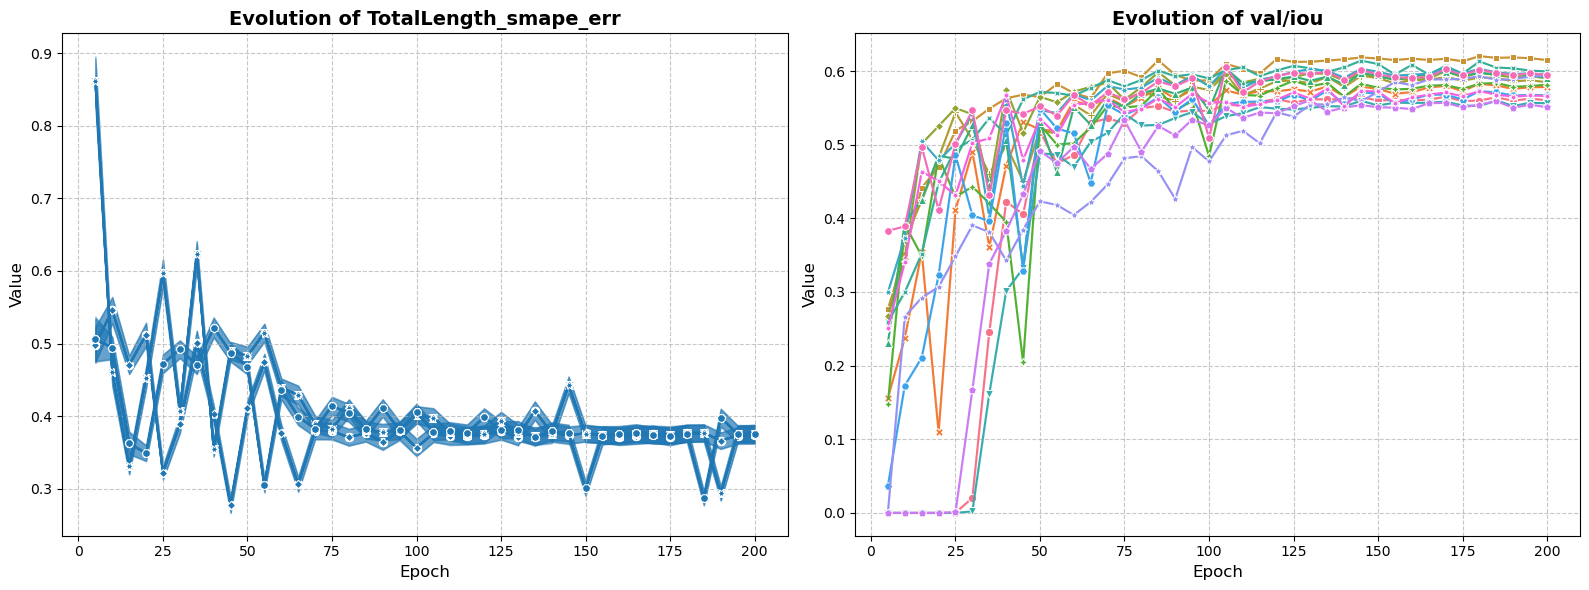

In [39]:
plot_evolution(
    df= df_diff_log,
    plant_metric='TotalLength_smape_err',
    img_metric='val/iou',
    selected_model='all', 
    selected_loss='all'
)

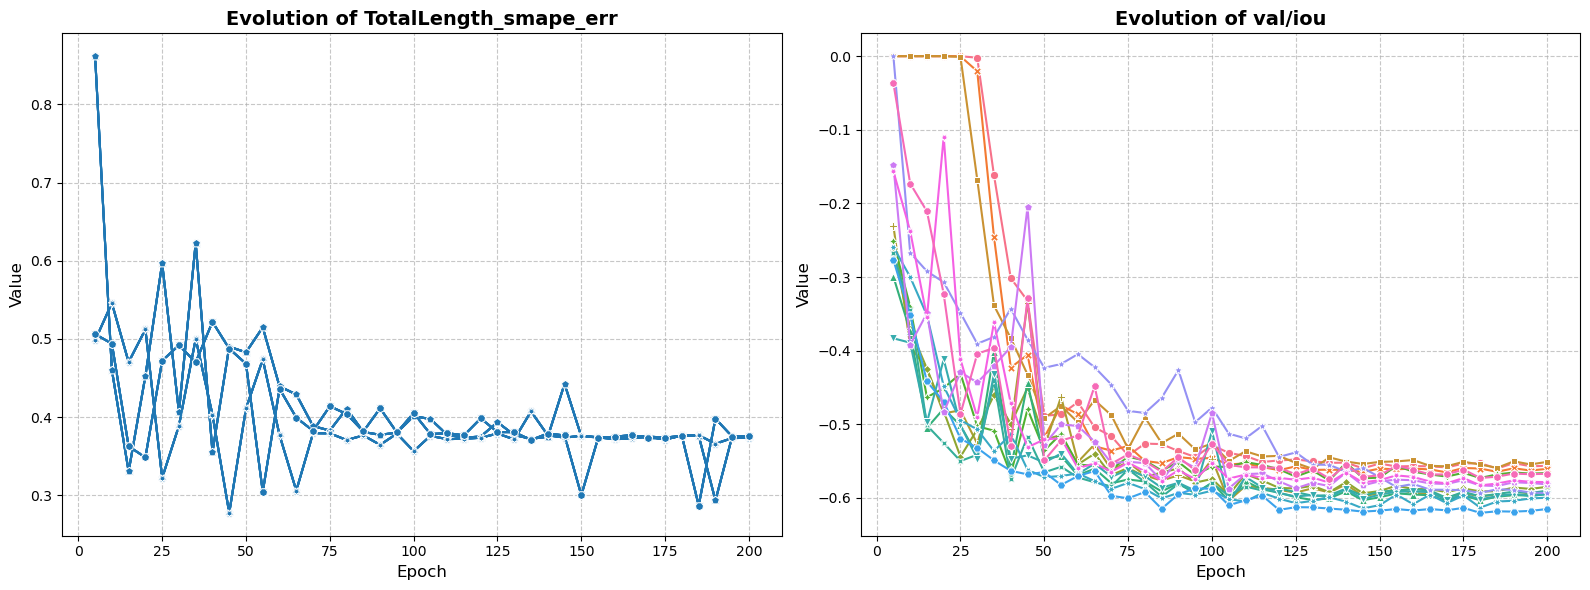

In [40]:
plot_evolution(
    df=df_diff_log_epoch_mean,
    plant_metric='TotalLength_smape_err',
    img_metric='val/iou',
    selected_model='all',
    selected_loss='all'
)

## Ranking tables

  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: scalar or None
  animated: bool
  antialiased: bool
  backgroundcolor: :mpltype:`color`
  bbox: dict with properties for `.patches.FancyBboxPatch`
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  color or c: :mpltype:`color`
  figure: `~matplotlib.figure.Figure`
  fontfamily or family or fontname: {FONTNAME, 'serif', 'sans-serif', 'cursive', 'fantasy', 'monospace'}
  fontproperties or font or font_properties: `.font_manager.FontProperties` or `str` or `pathlib.Path`
  fontsize or size: float or {'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'}
  fontstretch or stretch: {a numeric value in range 0-1000, 'ultra-condensed', 'extra-condensed', 'condensed', 'semi-condensed', 'normal', 'semi-expanded', 'expanded', 'ext

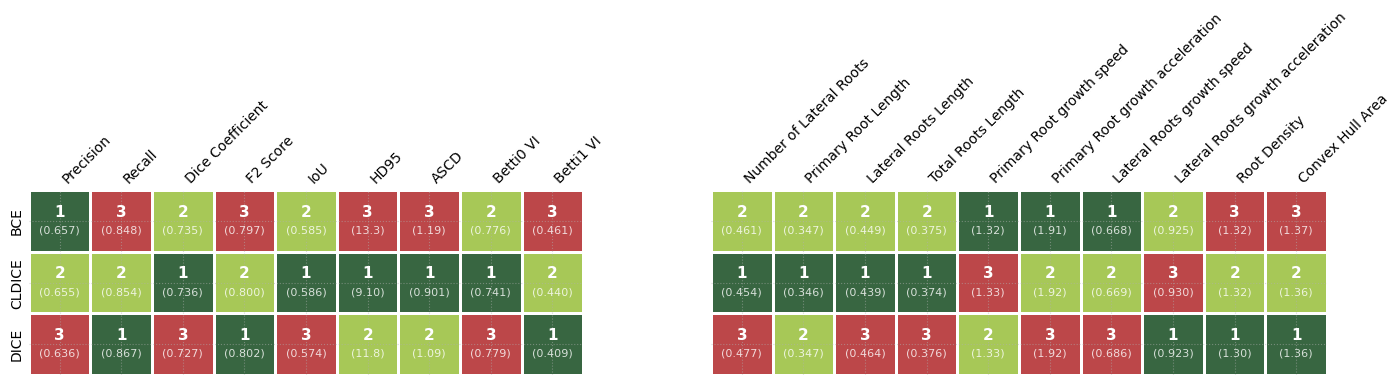

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

df_diff_log2 = df_diff_log.copy()
last_epoch_df = df_diff_log2[df_diff_log2['epoch'] == df_diff_log2.groupby(['loss'])['epoch'].transform('max')]

target_plant_metrics = plant_smape_err
cols_to_agg = img_metrics + target_plant_metrics
df_last_agg = last_epoch_df.groupby(['loss'])[cols_to_agg].mean().reset_index()

df_ranks = pd.DataFrame()
df_ranks['config'] = df_last_agg['loss'] 

precision = 3

for metric in img_metrics:
    values = df_last_agg[metric].dropna().astype(float)
    rounded_series = values.round(precision)
    if metric in scores_img_metrics:
        df_ranks[metric] = rounded_series.rank(ascending=False, method='dense')
    else:
        df_ranks[metric] = rounded_series.rank(ascending=True, method='dense')
        
for metric in target_plant_metrics:
    # keep only non-NaN values for ranking, and rank in ascending order (lower error is better)
    values = df_last_agg[metric].dropna().astype(float)
    rounded_series = values.round(precision)
    df_ranks[metric] = rounded_series.rank(ascending=True, method='dense')
    
df_ranks_plot = df_ranks.set_index('config')[cols_to_agg]
df_vals_plot = df_last_agg.copy()
df_vals_plot['config'] = df_vals_plot['loss']
df_vals_plot = df_vals_plot.set_index('config')[cols_to_agg]

df_ranks_plot.columns = [renaming_dict.get(col, col) for col in df_ranks_plot.columns]
df_vals_plot.columns = [renaming_dict.get(col, col) for col in df_vals_plot.columns]

def format_val(v):
    if pd.isna(v): return ""
    if abs(v) >= 100: return f"({v:.0f})"     
    elif abs(v) >= 10: return f"({v:.1f})"    
    elif abs(v) >= 1: return f"({v:.2f})"     
    else: return f"({v:.3f})"
    
import matplotlib.colors as mcolors

def plot_minimalist_ranking_heatmap(img_metrics, plant_metrics, save_filename):
    # Préparation des labels
    renamed_img = [renaming_dict.get(m, m) for m in img_metrics]
    renamed_plant = [renaming_dict.get(m, m) for m in plant_metrics]
    
    # On définit une taille de cellule fixe (ex: 0.8 inch par case)
    cell_size = 0.8
    n_rows = len(df_ranks_plot)
    n_cols_total = len(renamed_img) + len(renamed_plant)
    
    # Calcul de la taille de la figure pour garder les cases carrées
    fig_width = (n_cols_total * cell_size) + 2 # + marge pour labels y
    fig_height = (n_rows * cell_size)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(fig_width, fig_height), 
                                   gridspec_kw={'width_ratios': [len(renamed_img), len(renamed_plant)],
                                                'wspace': 0.15}) # Espace entre les deux

    # Colormap : Vert (1) -> Noir (Milieu) -> Rouge (Pire)
    colors = ["#386641", "#a7c957", "#bc4749"] 
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("linear_div", colors, N=256)

    def draw_sub_heatmap(ax, metrics, show_yticklabels=True):
        df_r = df_ranks_plot[metrics]
        df_v = df_vals_plot[metrics]
        vmax_global = df_ranks_plot.max().max()
        
        sns.heatmap(df_r, 
                    annot=False, 
                    cmap=custom_cmap, 
                    vmin=1, vmax=vmax_global,
                    linewidths=2,           
                    linecolor='white',
                    square=True, # FORCE LES CASES CARRÉES
                    cbar=False,
                    ax=ax)

        # On garde les labels de colonnes en haut
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')
        plt.setp(ax.get_xticklabels(), rotation=45, ha="left", fontsize=10)
        
        # Nettoyage complet
        ax.tick_params(axis='both', which='both', length=0)
        ax.set_xlabel("")
        ax.set_ylabel("")
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Texte dans les cases
        for i in range(df_r.shape[0]):
            for j in range(df_r.shape[1]):
                rank = df_r.iat[i, j]
                val = df_v.iat[i, j]
                
                # Couleur du texte adaptative (blanc sur fond sombre)
                norm_pos = (rank - 1) / (vmax_global - 1)
                text_color =  "white"
                
                rank_str = f"{rank:.0f}"
                ax.text(j + 0.5, i + 0.35, rank_str, ha='center', va='center', 
                        weight='bold', fontsize=11, color=text_color)
                ax.text(j + 0.5, i + 0.65, format_val(val), ha='center', va='center', 
                        fontsize=8, color=text_color, alpha=0.8)

        if not show_yticklabels:
            ax.set_yticklabels([])
        else:
            plt.setp(ax.get_yticklabels())

    # Exécution
    draw_sub_heatmap(ax1, renamed_img, show_yticklabels=True)
    draw_sub_heatmap(ax2, renamed_plant, show_yticklabels=False)

    # Sauvegarde sans marges inutiles
    plt.savefig(save_filename, dpi=600, bbox_inches='tight', transparent=True)
    plt.show()

# Appel
plot_minimalist_ranking_heatmap(
    img_metrics=img_metrics,
    plant_metrics=target_plant_metrics,
    save_filename="heatmap_canva_ready.png"
)

## Corr tables
### Spearmann

Corrélation (ρ Spearman):


,TotalLength_smape_err,TotalOrganCount_smape_err,ConvexHullArea_smape_err,RootDensity_smape_err
val/precision,0.398,0.467,0.340,0.208
val/recall,0.198,0.391,0.356,0.374
val/iou,0.447,0.548,0.415,0.280
val/dice,0.448,0.549,0.415,0.277
val/f_2_score,0.419,0.584,0.467,0.389
val/f_4_score,0.290,0.490,0.421,0.414
val/hausdorff_max,0.204,0.291,0.144,0.062
val/hausdorff_95,0.313,0.434,0.247,0.142
val/ASCD,0.328,0.449,0.266,0.158
val/betti0_variation_index,0.372,0.501,0.323,0.202


p-values:


/tmp/ipykernel_127197/2111340707.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(Pvalues.applymap(lambda x: round(x, 3) if pd.notna(x) else x))


,TotalLength_smape_err,TotalOrganCount_smape_err,ConvexHullArea_smape_err,RootDensity_smape_err
val/precision,0.0,0.0,0.0,0.000
val/recall,0.0,0.0,0.0,0.000
val/iou,0.0,0.0,0.0,0.000
val/dice,0.0,0.0,0.0,0.000
val/f_2_score,0.0,0.0,0.0,0.000
val/f_4_score,0.0,0.0,0.0,0.000
val/hausdorff_max,0.0,0.0,0.0,0.133
val/hausdorff_95,0.0,0.0,0.0,0.001
val/ASCD,0.0,0.0,0.0,0.000
val/betti0_variation_index,0.0,0.0,0.0,0.000


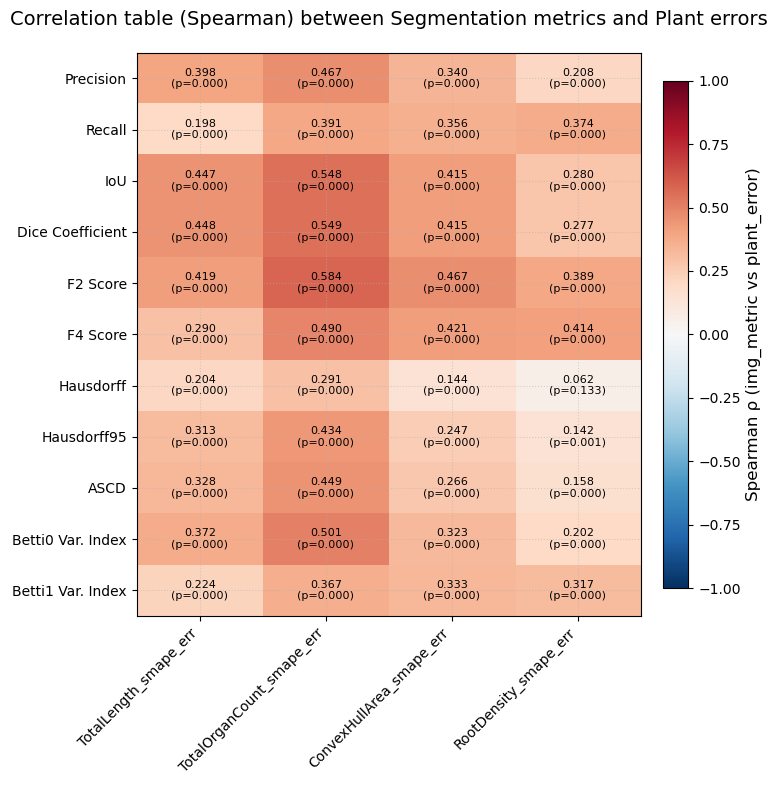

In [ ]:
import numpy as np
from scipy.stats import spearmanr

rho_rows, p_rows = [], []
for img_met in img_metrics:
    rho_row, p_row = {}, {}
    for plant_err in plant_smape_err:
        valid = df_diff_log_epoch_mean[[img_met, plant_err]].copy()
        if len(valid) < 3:
            rho, p = np.nan, np.nan
        else:
            valid = valid.replace([np.inf, -np.inf], np.nan).dropna()
            rho, p = spearmanr(valid[img_met], valid[plant_err])
        rho_row[plant_err] = float(rho) if np.isfinite(rho) else np.nan
        p_row[plant_err]   = float(p) if np.isfinite(p) else np.nan
    rho_rows.append(pd.Series(rho_row, name=img_met))
    p_rows.append(pd.Series(p_row, name=img_met))

CorrSpearman = pd.DataFrame(rho_rows)
Pvalues      = pd.DataFrame(p_rows)

print("Corrélation (ρ Spearman):")
display(CorrSpearman.round(3))

print("p-values:")
display(Pvalues.applymap(lambda x: round(x, 3) if pd.notna(x) else x))

# --- Heatmap simple (matplotlib) centrée sur 0 ---
plt.figure(figsize=(1.2*len(plant_smape_err)+3, 0.45*len(img_metrics)+3))
im = plt.imshow(CorrSpearman.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Spearman ρ (img_metric vs plant_error)")
plt.yticks(range(len(img_metrics)), [renaming_img_dict.get(m, m) for m in img_metrics], fontsize=10)
plt.xticks(range(len(plant_smape_err)), plant_smape_err, rotation=45, ha="right")
plt.title("Correlation table (Spearman) between Segmentation metrics and Plant errors", pad=20)

for i in range(len(img_metrics)):
    for j in range(len(plant_smape_err)):
        rho = CorrSpearman.iat[i, j]
        p = Pvalues.iat[i, j]
        txt = "" if np.isnan(rho) else f"{rho:.3f}\n(p={p:.3f})"
        plt.text(j, i, txt, ha='center', va='center', fontsize=8, color="black")
plt.tight_layout()
plt.savefig("corr_img_to_plant_error_spearman.png", transparent=True, dpi=1200)
plt.show()

Corrélation (ρ Spearman):


,TotalLength_smape_err,TotalOrganCount_smape_err,ConvexHullArea_smape_err,RootDensity_smape_err
val/precision,0.033,-0.108,-0.044,-0.073
val/recall,0.043,0.186,0.254,0.281
val/iou,0.081,0.001,0.050,0.029
val/dice,0.082,0.006,0.049,0.027
val/f_2_score,0.101,0.173,0.180,0.179
val/f_4_score,0.058,0.192,0.245,0.267
val/hausdorff_max,-0.054,-0.025,-0.195,-0.250
val/hausdorff_95,-0.001,0.037,-0.100,-0.162
val/ASCD,0.019,0.033,-0.053,-0.105
val/betti0_variation_index,0.009,0.088,-0.113,-0.189


p-values:


/tmp/ipykernel_127197/360855680.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(Pvalues.applymap(lambda x: round(x, 3) if pd.notna(x) else x))


,TotalLength_smape_err,TotalOrganCount_smape_err,ConvexHullArea_smape_err,RootDensity_smape_err
val/precision,0.435,0.010,0.291,0.081
val/recall,0.300,0.000,0.000,0.000
val/iou,0.051,0.981,0.234,0.488
val/dice,0.050,0.888,0.242,0.520
val/f_2_score,0.016,0.000,0.000,0.000
val/f_4_score,0.168,0.000,0.000,0.000
val/hausdorff_max,0.203,0.551,0.000,0.000
val/hausdorff_95,0.972,0.384,0.017,0.000
val/ASCD,0.654,0.440,0.206,0.013
val/betti0_variation_index,0.828,0.035,0.007,0.000


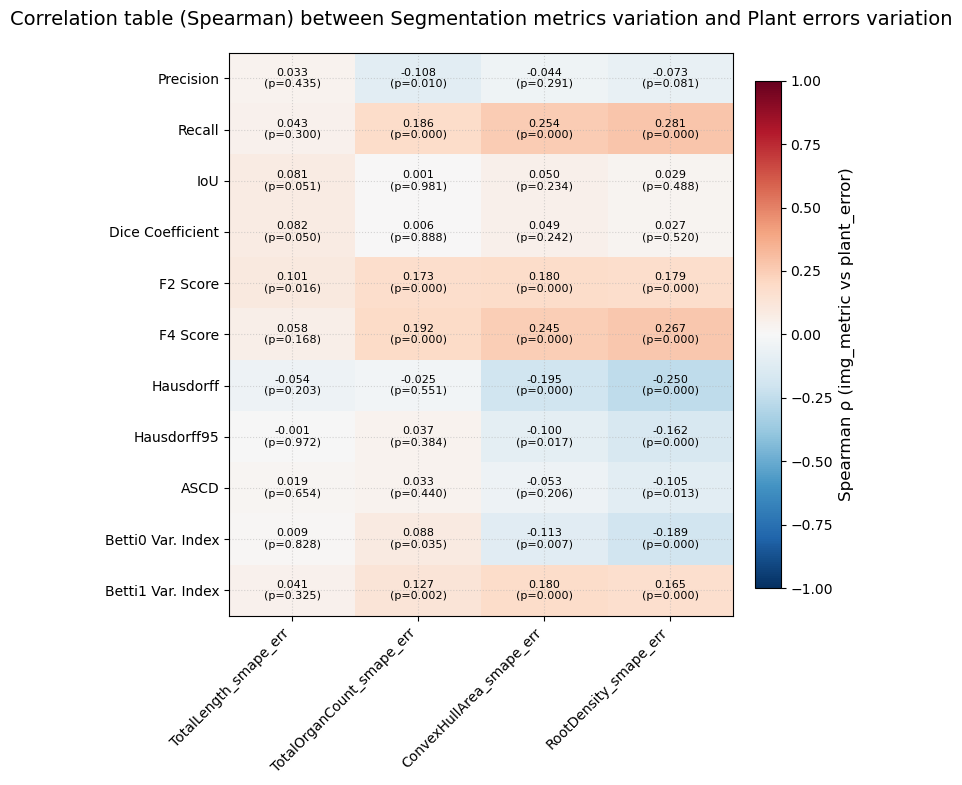

In [ ]:
import numpy as np
from scipy.stats import spearmanr


rho_rows, p_rows = [], []
for img_met in img_metrics:
    rho_row, p_row = {}, {}
    for plant_err in plant_smape_err:
        #valid = df_diff_log[[img_met, plant_err]].dropna().copy()
        valid = df_morpho_deltas[[img_met, plant_err]].copy()
        if len(valid) < 3:
            rho, p = np.nan, np.nan
        else:
            valid = valid.replace([np.inf, -np.inf], np.nan).dropna()
            rho, p = spearmanr(valid[img_met], valid[plant_err])
        rho_row[plant_err] = float(rho) if np.isfinite(rho) else np.nan
        p_row[plant_err]   = float(p) if np.isfinite(p) else np.nan
    rho_rows.append(pd.Series(rho_row, name=img_met))
    p_rows.append(pd.Series(p_row, name=img_met))

CorrSpearman = pd.DataFrame(rho_rows)
Pvalues      = pd.DataFrame(p_rows)

print("Corrélation (ρ Spearman):")
display(CorrSpearman.round(3))

print("p-values:")
display(Pvalues.applymap(lambda x: round(x, 3) if pd.notna(x) else x))

# --- Heatmap simple (matplotlib) centrée sur 0 ---
plt.figure(figsize=(1.2*len(plant_smape_err)+3, 0.45*len(img_metrics)+3))
im = plt.imshow(CorrSpearman.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Spearman ρ (img_metric vs plant_error)")
plt.yticks(range(len(img_metrics)), [renaming_img_dict.get(m, m) for m in img_metrics], fontsize=10)
plt.xticks(range(len(plant_smape_err)), plant_smape_err, rotation=45, ha="right")
plt.title("Correlation table (Spearman) between Segmentation metrics variation and Plant errors variation", pad=20)

# Annotations: ρ
for i in range(len(img_metrics)):
    for j in range(len(plant_smape_err)):
        rho = CorrSpearman.iat[i, j]
        p = Pvalues.iat[i, j]
        txt = "" if np.isnan(rho) else f"{rho:.3f}\n(p={p:.3f})"
        plt.text(j, i, txt, ha='center', va='center', fontsize=8, color="black")
plt.tight_layout()
plt.savefig("corr_img_to_plant_error_spearman.png", transparent=True, dpi=600)
plt.show()

# Option: export CSV
#CorrSpearman.to_csv("corr_img_to_plant_error_spearman.csv")
#Pvalues.to_csv("corr_img_to_plant_error_spearman_pvalues.csv")

### Pearsonn

Corrélation (R2 Pearson):


,TotalLength_smape_err,TotalOrganCount_smape_err,ConvexHullArea_smape_err,RootDensity_smape_err
val/precision,0.462,0.613,0.641,0.621
val/recall,0.343,0.514,0.518,0.515
val/iou,0.495,0.680,0.689,0.670
val/dice,0.462,0.639,0.661,0.646
val/f_2_score,0.428,0.608,0.625,0.615
val/f_4_score,0.384,0.560,0.571,0.566
val/hausdorff_max,0.225,0.308,0.273,0.248
val/hausdorff_95,0.437,0.584,0.545,0.512
val/ASCD,0.489,0.596,0.656,0.637
val/betti0_variation_index,0.408,0.551,0.481,0.450


p-values:


/tmp/ipykernel_201210/390263095.py:27: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(Pvalues.applymap(lambda x: round(x, 3) if pd.notna(x) else x))


,TotalLength_smape_err,TotalOrganCount_smape_err,ConvexHullArea_smape_err,RootDensity_smape_err
val/precision,0.0,0.0,0.0,0.0
val/recall,0.0,0.0,0.0,0.0
val/iou,0.0,0.0,0.0,0.0
val/dice,0.0,0.0,0.0,0.0
val/f_2_score,0.0,0.0,0.0,0.0
val/f_4_score,0.0,0.0,0.0,0.0
val/hausdorff_max,0.0,0.0,0.0,0.0
val/hausdorff_95,0.0,0.0,0.0,0.0
val/ASCD,0.0,0.0,0.0,0.0
val/betti0_variation_index,0.0,0.0,0.0,0.0


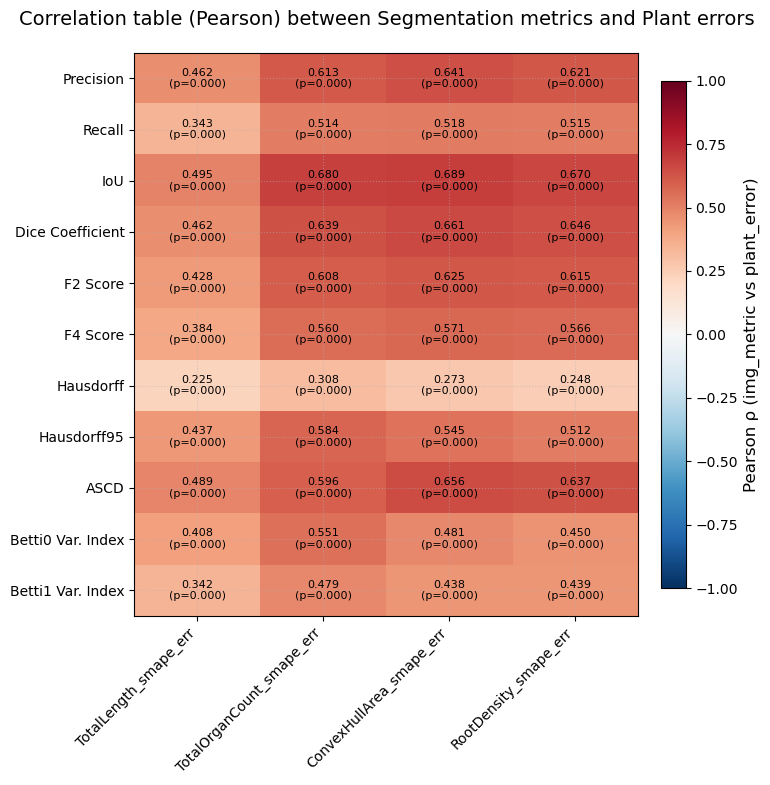

In [ ]:
import numpy as np
from scipy.stats import pearsonr

rho_rows, p_rows = [], []
for img_met in img_metrics:
    rho_row, p_row = {}, {}
    for plant_err in plant_smape_err:
        #valid = df_diff_log[[img_met, plant_err]].dropna().copy()
        valid = df_diff_log_epoch_mean[[img_met, plant_err]].copy()
        if len(valid) < 3:
            rho, p = np.nan, np.nan
        else:
            valid_metrics = valid.replace([np.inf, -np.inf], np.nan).dropna()
            rho, p = pearsonr(valid_metrics[img_met], valid_metrics[plant_err])
        rho_row[plant_err] = float(rho) if np.isfinite(rho) else np.nan
        p_row[plant_err]   = float(p) if np.isfinite(p) else np.nan
    rho_rows.append(pd.Series(rho_row, name=img_met))
    p_rows.append(pd.Series(p_row, name=img_met))

CorrPearson = pd.DataFrame(rho_rows)
Pvalues      = pd.DataFrame(p_rows)

print("Corrélation (R2 Pearson):")
display(CorrPearson.round(3))

print("p-values:")
display(Pvalues.applymap(lambda x: round(x, 3) if pd.notna(x) else x))

# --- Heatmap simple (matplotlib) centrée sur 0 ---
plt.figure(figsize=(1.2*len(plant_smape_err)+3, 0.45*len(img_metrics)+3))
im = plt.imshow(CorrPearson.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Pearson ρ (img_metric vs plant_error)")
plt.yticks(range(len(img_metrics)), [renaming_img_dict.get(m, m) for m in img_metrics], fontsize=10)
plt.xticks(range(len(plant_smape_err)), plant_smape_err, rotation=45, ha="right")
plt.title("Correlation table (Pearson) between Segmentation metrics and Plant errors", pad=20)

# Annotations: ρ
for i in range(len(img_metrics)):
    for j in range(len(plant_smape_err)):
        rho = CorrPearson.iat[i, j]
        p = Pvalues.iat[i, j]
        txt = "" if np.isnan(rho) else f"{rho:.3f}\n(p={p:.3f})"
        plt.text(j, i, txt, ha='center', va='center', fontsize=8, color="black")
plt.tight_layout()
plt.savefig("corr_img_to_plant_error_pearson.png", transparent=True, dpi=600)
plt.show()

# Option: export CSV
#CorrSpearman.to_csv("corr_img_to_plant_error_spearman.csv")

Corrélation (R2 Pearson):


,TotalLength_smape_err,TotalOrganCount_smape_err,ConvexHullArea_smape_err,RootDensity_smape_err
val/precision,0.128,0.054,-0.022,-0.023
val/recall,0.105,0.162,0.310,0.327
val/iou,0.214,0.212,0.204,0.201
val/dice,0.199,0.175,0.202,0.202
val/f_2_score,0.191,0.217,0.294,0.305
val/f_4_score,0.149,0.197,0.318,0.334
val/hausdorff_max,-0.033,-0.050,-0.197,-0.222
val/hausdorff_95,0.094,0.082,-0.047,-0.081
val/ASCD,0.143,0.055,-0.020,-0.029
val/betti0_variation_index,0.087,0.112,-0.063,-0.088


p-values:


/tmp/ipykernel_201210/239582657.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(Pvalues.applymap(lambda x: round(x, 3) if pd.notna(x) else x))


,TotalLength_smape_err,TotalOrganCount_smape_err,ConvexHullArea_smape_err,RootDensity_smape_err
val/precision,0.002,0.198,0.600,0.576
val/recall,0.012,0.000,0.000,0.000
val/iou,0.000,0.000,0.000,0.000
val/dice,0.000,0.000,0.000,0.000
val/f_2_score,0.000,0.000,0.000,0.000
val/f_4_score,0.000,0.000,0.000,0.000
val/hausdorff_max,0.438,0.235,0.000,0.000
val/hausdorff_95,0.025,0.050,0.260,0.055
val/ASCD,0.001,0.190,0.636,0.497
val/betti0_variation_index,0.036,0.007,0.131,0.034


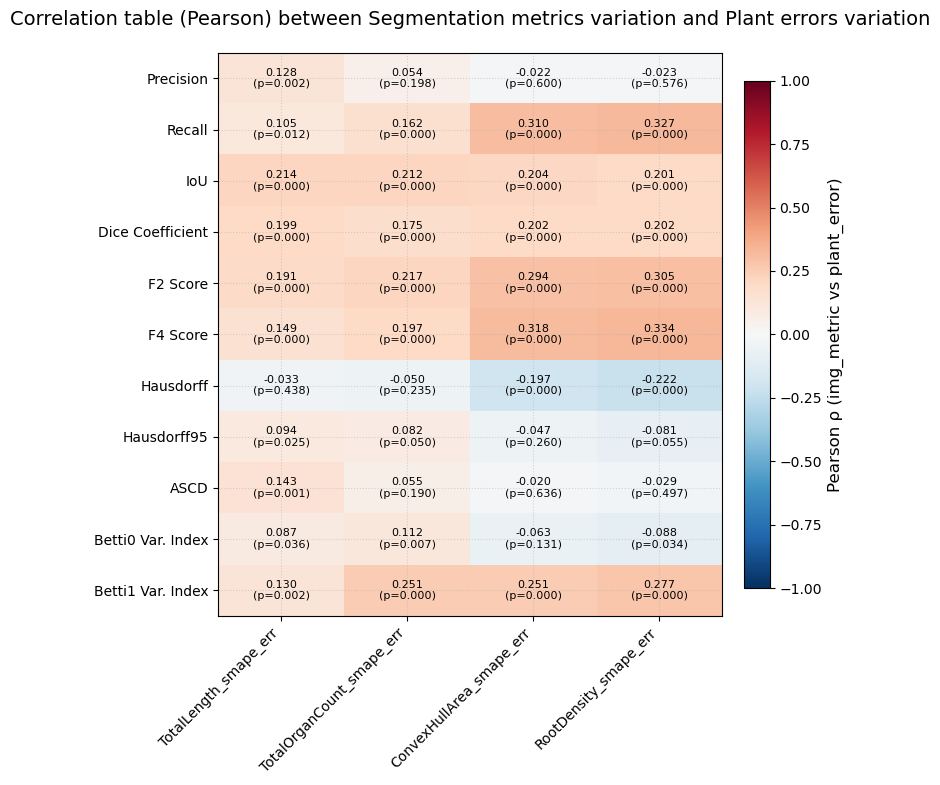

In [ ]:
import numpy as np
from scipy.stats import pearsonr


rho_rows, p_rows = [], []
for img_met in img_metrics:
    rho_row, p_row = {}, {}
    for plant_err in plant_smape_err:
        #valid = df_diff_log[[img_met, plant_err]].dropna().copy()
        valid = df_morpho_deltas[[img_met, plant_err]].copy()
        if len(valid) < 3:
            rho, p = np.nan, np.nan
        else:
            valid = valid.replace([np.inf, -np.inf], np.nan).dropna()
            rho, p = pearsonr(valid[img_met], valid[plant_err])
        rho_row[plant_err] = float(rho) if np.isfinite(rho) else np.nan
        p_row[plant_err]   = float(p) if np.isfinite(p) else np.nan
    rho_rows.append(pd.Series(rho_row, name=img_met))
    p_rows.append(pd.Series(p_row, name=img_met))

CorrPearson = pd.DataFrame(rho_rows)
Pvalues      = pd.DataFrame(p_rows)

print("Corrélation (R2 Pearson):")
display(CorrPearson.round(3))

print("p-values:")
display(Pvalues.applymap(lambda x: round(x, 3) if pd.notna(x) else x))

# --- Heatmap simple (matplotlib) centrée sur 0 ---
plt.figure(figsize=(1.2*len(plant_smape_err)+3, 0.45*len(img_metrics)+3))
im = plt.imshow(CorrPearson.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Pearson ρ (img_metric vs plant_error)")
plt.yticks(range(len(img_metrics)), [renaming_img_dict.get(m, m) for m in img_metrics], fontsize=10)
plt.xticks(range(len(plant_smape_err)), plant_smape_err, rotation=45, ha="right")
plt.title("Correlation table (Pearson) between Segmentation metrics variation and Plant errors variation", pad=20)

# Annotations: ρ
for i in range(len(img_metrics)):
    for j in range(len(plant_smape_err)):
        rho = CorrPearson.iat[i, j]
        p = Pvalues.iat[i, j]
        txt = "" if np.isnan(rho) else f"{rho:.3f}\n(p={p:.3f})"
        plt.text(j, i, txt, ha='center', va='center', fontsize=8, color="black")
plt.tight_layout()
plt.savefig("corr_img_to_plant_error_pearson.png", transparent=True, dpi=600)
plt.show()

# Option: export CSV
#CorrSpearman.to_csv("corr_img_to_plant_error_spearman.csv")
#Pvalues.to_csv("corr_img_to_plant_error_spearman_pvalues.csv")

## Losses

### Spearmann

Corrélation (ρ Spearman):


,TotalLength_smape_err,TotalOrganCount_smape_err,ConvexHullArea_smape_err,RootDensity_smape_err
BCE,0.256,0.312,0.353,0.306
DICE,0.240,0.369,0.233,0.156
CLDICE,0.234,0.347,0.234,0.236


p-values:


/tmp/ipykernel_201210/912704206.py:33: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(Pvalues_loss.applymap(lambda x: round(x, 3) if pd.notna(x) else x))


,TotalLength_smape_err,TotalOrganCount_smape_err,ConvexHullArea_smape_err,RootDensity_smape_err
BCE,0.000,0.0,0.000,0.000
DICE,0.001,0.0,0.001,0.027
CLDICE,0.001,0.0,0.001,0.001


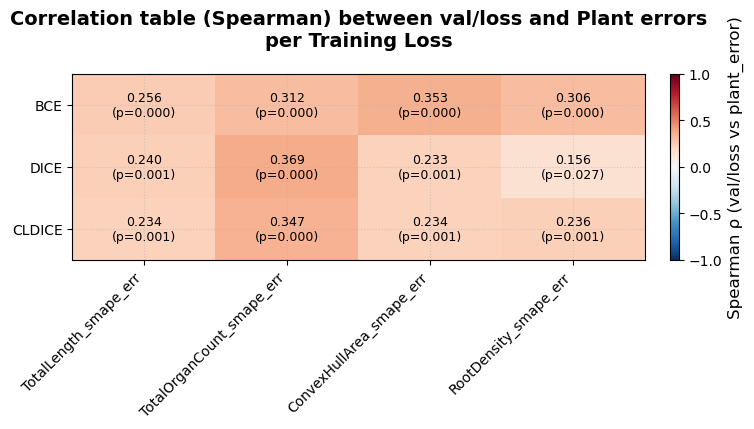

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

losses = ['BCE', 'DICE', 'CLDICE']
loss_metrics = ['val/loss']

rho_rows, p_rows = [], []
for loss in losses:
    rho_row, p_row = {}, {}
    for plant_err in plant_smape_err:
        df_diff_log_epoch_mean_loss = df_diff_log_epoch_mean[df_diff_log_epoch_mean['loss'] == loss]
        valid = df_diff_log_epoch_mean_loss[[loss_metrics[0], plant_err]].copy()
        if len(valid) < 3:
            rho, p = np.nan, np.nan
        else:
            valid = valid.replace([np.inf, -np.inf], np.nan).dropna()
            rho, p = spearmanr(valid[loss_metrics[0]], valid[plant_err])
        rho_row[plant_err] = float(rho) if np.isfinite(rho) else np.nan
        p_row[plant_err]   = float(p) if np.isfinite(p) else np.nan
        
    rho_rows.append(pd.Series(rho_row, name=loss))
    p_rows.append(pd.Series(p_row, name=loss))

CorrSpearman_loss = pd.DataFrame(rho_rows)
Pvalues_loss      = pd.DataFrame(p_rows)

print("Corrélation (ρ Spearman):")
display(CorrSpearman_loss.round(3))

print("p-values:")
display(Pvalues_loss.applymap(lambda x: round(x, 3) if pd.notna(x) else x))

# --- CORRECTION DE L'AFFICHAGE CI-DESSOUS ---

# On utilise len(losses) au lieu de len(loss_metrics) pour la taille
plt.figure(figsize=(1.2 * len(plant_smape_err) + 3, max(3, 0.8 * len(losses) + 2)))
im = plt.imshow(CorrSpearman_loss.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label=f"Spearman ρ ({loss_metrics[0]} vs plant_error)")

# On place les noms des losses (BCE, DICE, CLDICE) sur l'axe Y
plt.yticks(range(len(losses)), losses, fontsize=10)
plt.xticks(range(len(plant_smape_err)), plant_smape_err, rotation=45, ha="right")
plt.title(f"Correlation table (Spearman) between {loss_metrics[0]} and Plant errors\nper Training Loss", pad=20, fontsize=14, fontweight='bold')

# On itère sur les losses pour écrire le texte dans toutes les cases !
for i in range(len(losses)):
    for j in range(len(plant_smape_err)):
        rho = CorrSpearman_loss.iat[i, j]
        p = Pvalues_loss.iat[i, j]
        txt = "" if np.isnan(rho) else f"{rho:.3f}\n(p={p:.3f})"
        plt.text(j, i, txt, ha='center', va='center', fontsize=9, color="black")

plt.tight_layout()
plt.savefig("corr_loss_to_plant_error_spearman.png", transparent=True, dpi=600)
plt.show()

Corrélation (ρ Spearman):


,TotalLength_smape_err,TotalOrganCount_smape_err,ConvexHullArea_smape_err,RootDensity_smape_err
BCE,-0.065,-0.004,-0.115,-0.145
DICE,-0.078,-0.046,-0.057,-0.076
CLDICE,0.043,-0.007,-0.159,-0.172


p-values:


/tmp/ipykernel_201210/4245901511.py:33: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(Pvalues_loss.applymap(lambda x: round(x, 3) if pd.notna(x) else x))


,TotalLength_smape_err,TotalOrganCount_smape_err,ConvexHullArea_smape_err,RootDensity_smape_err
BCE,0.371,0.958,0.112,0.045
DICE,0.284,0.525,0.434,0.299
CLDICE,0.550,0.919,0.028,0.017


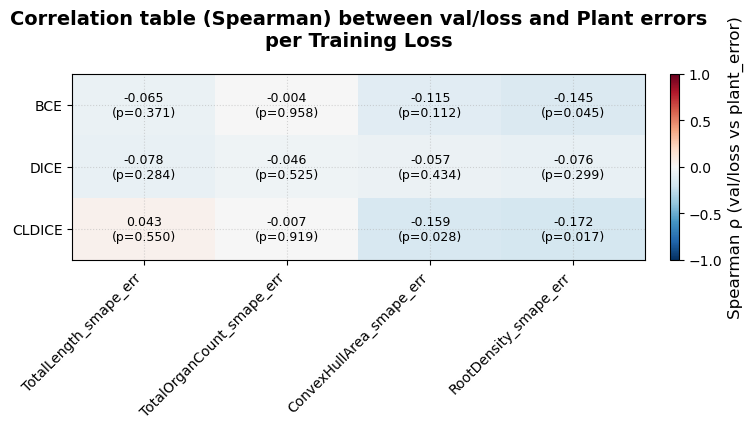

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

losses = ['BCE', 'DICE', 'CLDICE']
loss_metrics = ['val/loss']

rho_rows, p_rows = [], []
for loss in losses:
    rho_row, p_row = {}, {}
    for plant_err in plant_smape_err:
        df_morpho_deltas_loss = df_morpho_deltas[df_morpho_deltas['loss'] == loss]
        valid = df_morpho_deltas_loss[[loss_metrics[0], plant_err]].copy()
        if len(valid) < 3:
            rho, p = np.nan, np.nan
        else:
            valid = valid.replace([np.inf, -np.inf], np.nan).dropna()
            rho, p = spearmanr(valid[loss_metrics[0]], valid[plant_err])
        rho_row[plant_err] = float(rho) if np.isfinite(rho) else np.nan
        p_row[plant_err]   = float(p) if np.isfinite(p) else np.nan
        
    rho_rows.append(pd.Series(rho_row, name=loss))
    p_rows.append(pd.Series(p_row, name=loss))

CorrSpearman_loss = pd.DataFrame(rho_rows)
Pvalues_loss      = pd.DataFrame(p_rows)

print("Corrélation (ρ Spearman):")
display(CorrSpearman_loss.round(3))

print("p-values:")
display(Pvalues_loss.applymap(lambda x: round(x, 3) if pd.notna(x) else x))


plt.figure(figsize=(1.2 * len(plant_smape_err) + 3, max(3, 0.8 * len(losses) + 2)))
im = plt.imshow(CorrSpearman_loss.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label=f"Spearman ρ ({loss_metrics[0]} vs plant_error)")

# On place les noms des losses (BCE, DICE, CLDICE) sur l'axe Y
plt.yticks(range(len(losses)), losses, fontsize=10)
plt.xticks(range(len(plant_smape_err)), plant_smape_err, rotation=45, ha="right")
plt.title(f"Correlation table (Spearman) between {loss_metrics[0]} and Plant errors\nper Training Loss", pad=20, fontsize=14, fontweight='bold')

# On itère sur les losses pour écrire le texte dans toutes les cases !
for i in range(len(losses)):
    for j in range(len(plant_smape_err)):
        rho = CorrSpearman_loss.iat[i, j]
        p = Pvalues_loss.iat[i, j]
        txt = "" if np.isnan(rho) else f"{rho:.3f}\n(p={p:.3f})"
        plt.text(j, i, txt, ha='center', va='center', fontsize=9, color="black")

plt.tight_layout()
plt.savefig("corr_loss_to_plant_error_spearman.png", transparent=True, dpi=600)
plt.show()

### Pearson

Corrélation (ρ Pearson):


,TotalLength_smape_err,TotalOrganCount_smape_err,ConvexHullArea_smape_err,RootDensity_smape_err
BCE,0.322,0.414,0.421,0.413
DICE,0.193,0.286,0.237,0.220
CLDICE,0.276,0.356,0.341,0.338


p-values:


/tmp/ipykernel_201210/1669851743.py:33: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(Pvalues_loss.applymap(lambda x: round(x, 3) if pd.notna(x) else x))


,TotalLength_smape_err,TotalOrganCount_smape_err,ConvexHullArea_smape_err,RootDensity_smape_err
BCE,0.000,0.0,0.000,0.000
DICE,0.006,0.0,0.001,0.002
CLDICE,0.000,0.0,0.000,0.000


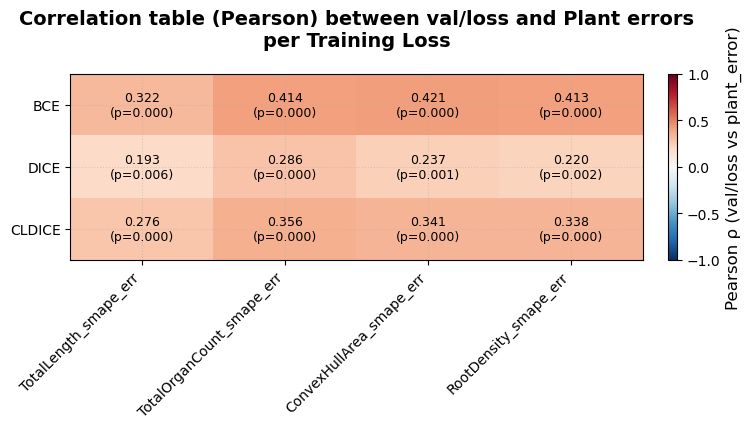

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

losses = ['BCE', 'DICE', 'CLDICE']
loss_metrics = ['val/loss']

rho_rows, p_rows = [], []
for loss in losses:
    rho_row, p_row = {}, {}
    for plant_err in plant_smape_err:
        df_diff_log_epoch_mean_loss = df_diff_log_epoch_mean[df_diff_log_epoch_mean['loss'] == loss]
        valid = df_diff_log_epoch_mean_loss[[loss_metrics[0], plant_err]].copy()
        if len(valid) < 3:
            rho, p = np.nan, np.nan
        else:
            valid = valid.replace([np.inf, -np.inf], np.nan).dropna()
            rho, p = pearsonr(valid[loss_metrics[0]], valid[plant_err])
        rho_row[plant_err] = float(rho) if np.isfinite(rho) else np.nan
        p_row[plant_err]   = float(p) if np.isfinite(p) else np.nan
        
    rho_rows.append(pd.Series(rho_row, name=loss))
    p_rows.append(pd.Series(p_row, name=loss))

CorrPearson_loss = pd.DataFrame(rho_rows)
Pvalues_loss      = pd.DataFrame(p_rows)

print("Corrélation (ρ Pearson):")
display(CorrPearson_loss.round(3))

print("p-values:")
display(Pvalues_loss.applymap(lambda x: round(x, 3) if pd.notna(x) else x))

plt.figure(figsize=(1.2 * len(plant_smape_err) + 3, max(3, 0.8 * len(losses) + 2)))
im = plt.imshow(CorrPearson_loss.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label=f"Pearson ρ ({loss_metrics[0]} vs plant_error)")

# On place les noms des losses (BCE, DICE, CLDICE) sur l'axe Y
plt.yticks(range(len(losses)), losses, fontsize=10)
plt.xticks(range(len(plant_smape_err)), plant_smape_err, rotation=45, ha="right")
plt.title(f"Correlation table (Pearson) between {loss_metrics[0]} and Plant errors\nper Training Loss", pad=20, fontsize=14, fontweight='bold')

# On itère sur les losses pour écrire le texte dans toutes les cases !
for i in range(len(losses)):
    for j in range(len(plant_smape_err)):
        rho = CorrPearson_loss.iat[i, j]
        p = Pvalues_loss.iat[i, j]
        txt = "" if np.isnan(rho) else f"{rho:.3f}\n(p={p:.3f})"
        plt.text(j, i, txt, ha='center', va='center', fontsize=9, color="black")

plt.tight_layout()
plt.savefig("corr_loss_to_plant_error_pearson.png", transparent=True, dpi=600)
plt.show()

## Per window

Génération de la matrice de corrélation dynamique pour TotalLength_smape_err...


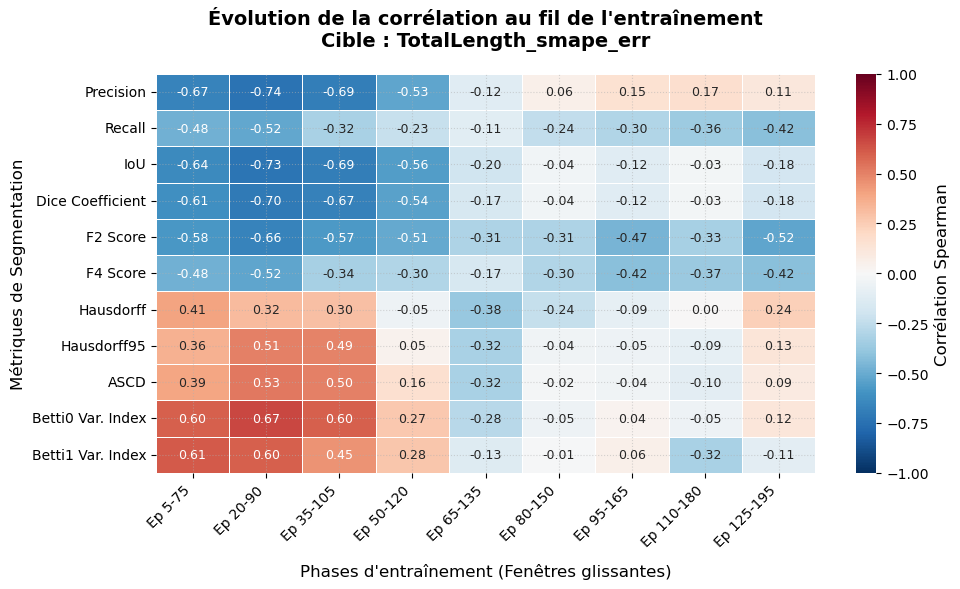

"\nfor plant_err in ['TotalLength_smape_err', 'TotalOrganCount_smape_err', 'RootDensity_smape_err']:\n    plot_rolling_correlation(\n        df_diff_log_epoch_mean, \n        plant_err, \n        img_metrics, \n        window_size=15, step=3\n    )\n"

In [ ]:
# %% [markdown]
# ## Dynamic Rolling Correlation Analysis

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

def plot_rolling_correlation(df, target_plant_metric, img_metrics_list, window_size=10, step=2, method='spearman'):
    """
    Calcule et affiche l'évolution de la corrélation entre une métrique plante cible 
    et une liste de métriques d'images, sur des fenêtres d'epochs glissantes.
    
    Paramètres:
    - df : DataFrame agrégé (ex: df_diff_log_epoch_mean)
    - target_plant_metric : str, l'erreur plante à analyser (ex: 'TotalLength_smape_err')
    - img_metrics_list : list, les métriques images à comparer
    - window_size : int, taille de la fenêtre (nombre d'epochs)
    - step : int, le pas pour avancer la fenêtre (détermine l'overlap)
    - method : 'spearman' ou 'pearson'
    """
    # 1. Préparation des données et des fenêtres
    # On s'assure de ne prendre que les données globales ou on moyenne par epoch
    df_agg = df.groupby('epoch')[img_metrics_list + [target_plant_metric]].mean().reset_index()
    epochs = sorted(df_agg['epoch'].dropna().unique())
    
    results = []
    window_labels = []
    
    # 2. Boucle sur les fenêtres glissantes
    for i in range(0, len(epochs) - window_size + 1, step):
        window_epochs = epochs[i : i + window_size]
        window_df = df_agg[df_agg['epoch'].isin(window_epochs)]
        
        # Création du label pour l'axe X (ex: "Ep 10-19")
        label = f"Ep {int(window_epochs[0])}-{int(window_epochs[-1])}"
        window_labels.append(label)
        
        corrs = {}
        for img_m in img_metrics_list:
            # Nettoyage des NaNs et infinis pour la fenêtre actuelle
            valid = window_df[[img_m, target_plant_metric]].replace([np.inf, -np.inf], np.nan).dropna()
            
            # Il faut un minimum de points pour calculer une corrélation (ex: 4)
            if len(valid) >= 4:
                if method == 'spearman':
                    corr, _ = spearmanr(valid[img_m], valid[target_plant_metric])
                else:
                    corr, _ = pearsonr(valid[img_m], valid[target_plant_metric])
            else:
                corr = np.nan
                
            corrs[img_m] = corr
            
        results.append(corrs)
        
    # 3. Formatage en DataFrame pour Seaborn
    # On transpose pour avoir les métriques en Y et les fenêtres de temps en X
    corr_df = pd.DataFrame(results, index=window_labels).T
    
    # Remplacement des noms de métriques par leurs versions "propres" si le dictionnaire existe
    if 'renaming_img_dict' in globals():
        corr_df.index = [renaming_img_dict.get(m, m) for m in corr_df.index]
    
    # 4. Visualisation (Heatmap Évolutive)
    plt.figure(figsize=(max(10, len(window_labels) * 0.8), max(6, len(img_metrics_list) * 0.4)))
    
    ax = sns.heatmap(
        corr_df, 
        annot=True,          # Affiche les valeurs
        fmt=".2f",           # 2 décimales
        cmap='RdBu_r',       # Rouge pour corrélation +, Bleu pour -
        center=0,            # Centre la colormap sur 0
        vmin=-1, vmax=1,     # Bornes de la corrélation
        cbar_kws={'label': f'Corrélation {method.capitalize()}'},
        linewidths=0.5,
        annot_kws={"size": 9}
    )
    
    plt.title(f"Évolution de la corrélation au fil de l'entraînement\nCible : {target_plant_metric}", 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel("Phases d'entraînement (Fenêtres glissantes)", fontsize=12, labelpad=10)
    plt.ylabel("Métriques de Segmentation", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    return corr_df

# %%
# --- Exemple d'utilisation ---

# On choisit l'erreur relative de la racine principale
metric_cible = 'TotalLength_smape_err'

# On lance l'analyse avec une fenêtre de 10 epochs qui avance de 2 en 2 (overlap de 8 epochs)
print(f"Génération de la matrice de corrélation dynamique pour {metric_cible}...")
df_rolling_corr = plot_rolling_correlation(
    df=df_morpho_log, 
    target_plant_metric=metric_cible, 
    img_metrics_list=img_metrics, 
    window_size=15,    # Ajustez selon la durée totale de votre entraînement (ex: 10, 15, 20)
    step=3,            # Avancement de la fenêtre
    method='spearman'  # 'spearman' capte mieux les relations non-linéaires
)

# %%
# Vous pouvez facilement boucler sur vos 3 erreurs végétales les plus importantes 
# pour générer les 3 graphiques d'un coup :
"""
for plant_err in ['TotalLength_smape_err', 'TotalOrganCount_smape_err', 'RootDensity_smape_err']:
    plot_rolling_correlation(
        df_diff_log_epoch_mean, 
        plant_err, 
        img_metrics, 
        window_size=15, step=3
    )
"""

Génération de la matrice d'importance globale des métriques d'images...


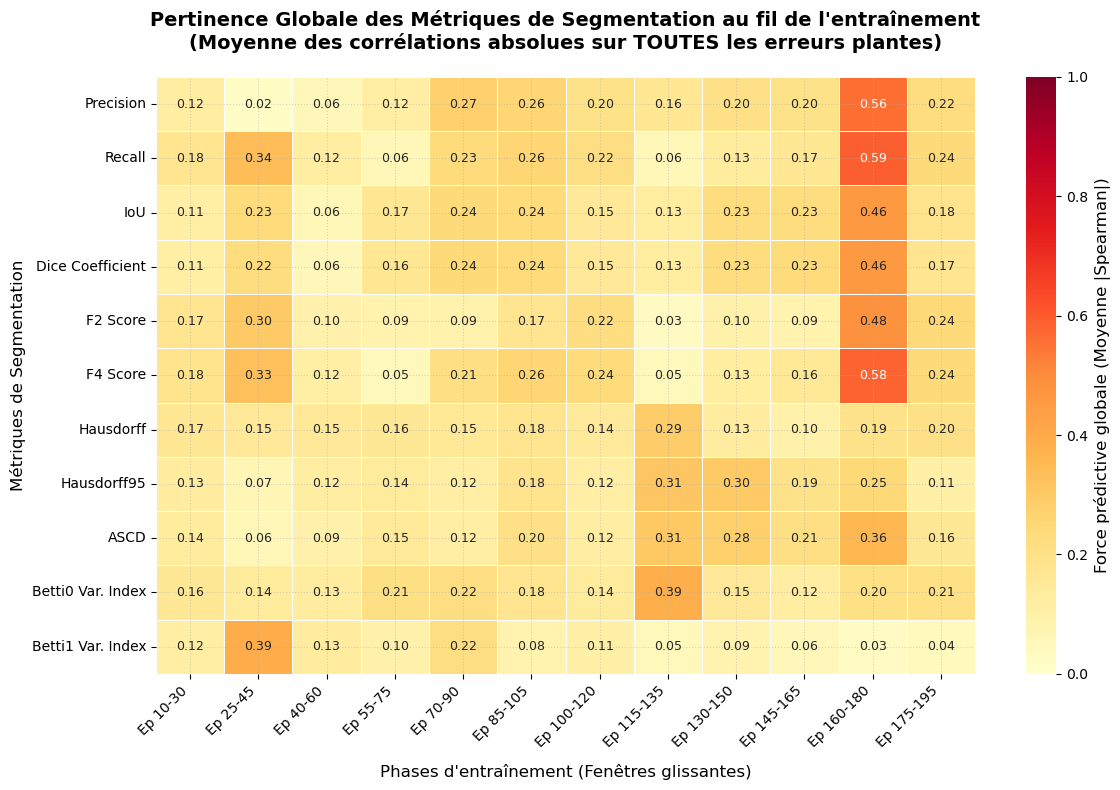

In [ ]:
# %% [markdown]
# ## Global Dynamic Rolling Correlation (All Plant Errors)

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

def plot_global_rolling_correlation(df, plant_metrics_list, img_metrics_list, window_size=10, step=2, method='spearman'):
    """
    Calcule la "force prédictive globale" de chaque métrique d'image sur TOUTES 
    les erreurs plantes confondues, en utilisant la moyenne des corrélations absolues.
    """
    results = []
    window_labels = []
    
    epochs = sorted(df['epoch'].dropna().unique())
    # 2. Boucle sur les fenêtres temporelles
    for i in range(0, len(epochs) - window_size + 1, step):
        window_epochs = epochs[i : i + window_size]
        window_df = df[df['epoch'].isin(window_epochs)]
        
        label = f"Ep {int(window_epochs[0])}-{int(window_epochs[-1])}"
        window_labels.append(label)
        
        window_corrs = {}
        
        # Pour chaque métrique d'image...
        for img_m in img_metrics_list:
            abs_correlations = []
            
            # ... on calcule sa corrélation avec TOUTES les erreurs plantes
            for plant_m in plant_metrics_list:
                valid = window_df[[img_m, plant_m]].replace([np.inf, -np.inf], np.nan).dropna()
                
                if len(valid) >= 4:
                    if method == 'spearman':
                        corr, _ = spearmanr(valid[img_m], valid[plant_m])
                    else:
                        corr, _ = pearsonr(valid[img_m], valid[plant_m])
                    
                    if not np.isnan(corr):
                        abs_correlations.append(abs(corr)) # VALEUR ABSOLUE
            
            # La force globale de l'img_metric est la moyenne de ces corrélations absolues
            window_corrs[img_m] = np.mean(abs_correlations) if abs_correlations else np.nan
            
        results.append(window_corrs)
        
    # 3. Formatage pour Seaborn
    corr_df = pd.DataFrame(results, index=window_labels).T
    
    if 'renaming_img_dict' in globals():
        corr_df.index = [renaming_img_dict.get(m, m) for m in corr_df.index]
        
    # 4. Visualisation (Heatmap de 0 à 1)
    plt.figure(figsize=(max(12, len(window_labels) * 0.8), max(8, len(img_metrics_list) * 0.4)))
    
    # Palette séquentielle car on va de 0 (aucune corrélation) à 1 (corrélation parfaite)
    sns.heatmap(
        corr_df, 
        annot=True, 
        fmt=".2f", 
        cmap='YlOrRd',       # Jaune (faible) vers Rouge foncé (fort)
        vmin=0, vmax=1,      # Echelle de 0 à 1
        cbar_kws={'label': f'Force prédictive globale (Moyenne |{method.capitalize()}|)'},
        linewidths=0.5,
        annot_kws={"size": 9}
    )
    
    plt.title("Pertinence Globale des Métriques de Segmentation au fil de l'entraînement\n(Moyenne des corrélations absolues sur TOUTES les erreurs plantes)", 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel("Phases d'entraînement (Fenêtres glissantes)", fontsize=12, labelpad=10)
    plt.ylabel("Métriques de Segmentation", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    return corr_df

toutes_les_erreurs_plantes = plant_smape_err 

print("Génération de la matrice d'importance globale des métriques d'images...")
df_global_importance = plot_global_rolling_correlation(
    df=df_morpho_deltas, 
    plant_metrics_list=toutes_les_erreurs_plantes, 
    img_metrics_list=img_metrics, 
    window_size=5,
    step=3, 
    method='spearman'
)

Génération de la matrice par phases (sans overlap)...


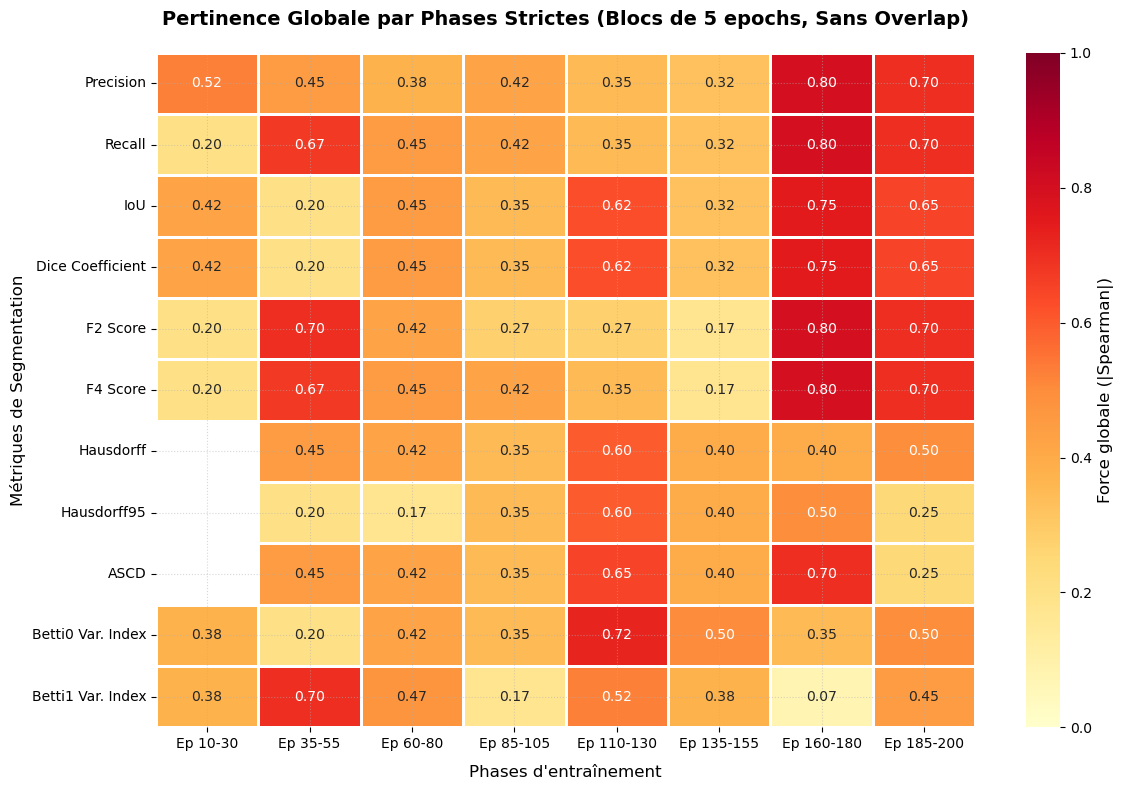

In [ ]:
# %% [markdown]
# ## Global Chunked Correlation (No Overlap)

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

def plot_global_chunked_correlation(df, plant_metrics_list, img_metrics_list, chunk_size=10, method='spearman'):
    """
    Évalue la force prédictive globale des métriques d'images sur des 
    phases d'entraînement strictes (sans aucun chevauchement).
    """
    # 1. Agréger par epoch
    cols_to_keep = img_metrics_list + plant_metrics_list
    df_agg = df.groupby('epoch')[cols_to_keep].mean().reset_index()
    epochs = sorted(df_agg['epoch'].dropna().unique())
    
    results = []
    window_labels = []
    
    # 2. Découpage en blocs consécutifs sans chevauchement
    chunks = [epochs[i:i + chunk_size] for i in range(0, len(epochs), chunk_size)]
    
    for chunk in chunks:
        # Sécurité : il faut au moins 4 points pour une corrélation robuste
        if len(chunk) < 4:
            print(f"Bloc Ep {int(chunk[0])}-{int(chunk[-1])} ignoré (trop peu d'epochs : {len(chunk)})")
            continue
            
        window_df = df_agg[df_agg['epoch'].isin(chunk)]
        label = f"Ep {int(chunk[0])}-{int(chunk[-1])}"
        window_labels.append(label)
        
        window_corrs = {}
        
        for img_m in img_metrics_list:
            abs_correlations = []
            
            for plant_m in plant_metrics_list:
                valid = window_df[[img_m, plant_m]].replace([np.inf, -np.inf], np.nan).dropna()
                
                if len(valid) >= 4:
                    if method == 'spearman':
                        corr, _ = spearmanr(valid[img_m], valid[plant_m])
                    else:
                        corr, _ = pearsonr(valid[img_m], valid[plant_m])
                    
                    if not np.isnan(corr):
                        abs_correlations.append(abs(corr))
            
            # Moyenne des valeurs absolues
            window_corrs[img_m] = np.mean(abs_correlations) if abs_correlations else np.nan
            
        results.append(window_corrs)
        
    # 3. Formatage pour Seaborn
    corr_df = pd.DataFrame(results, index=window_labels).T
    
    if 'renaming_img_dict' in globals():
        corr_df.index = [renaming_img_dict.get(m, m) for m in corr_df.index]
        
    # 4. Visualisation (Heatmap)
    plt.figure(figsize=(max(10, len(window_labels) * 1.5), max(8, len(img_metrics_list) * 0.4)))
    
    sns.heatmap(
        corr_df, 
        annot=True, 
        fmt=".2f", 
        cmap='YlOrRd',       
        vmin=0, vmax=1,      
        cbar_kws={'label': f'Force globale (|{method.capitalize()}|)'},
        linewidths=1,        # Des lignes plus épaisses pour bien séparer les phases
        linecolor='white',
        annot_kws={"size": 10}
    )
    
    plt.title(f"Pertinence Globale par Phases Strictes (Blocs de {chunk_size} epochs, Sans Overlap)", 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel("Phases d'entraînement", fontsize=12, labelpad=10)
    plt.ylabel("Métriques de Segmentation", fontsize=12)
    plt.xticks(rotation=0) # Rotation à 0 car les labels sont plus espacés sans l'overlap
    
    plt.tight_layout()
    plt.show()
    
    return corr_df

# %%
# --- Lancement de l'analyse par phases strictes ---

toutes_les_erreurs_plantes = plant_smape_err 

print("Génération de la matrice par phases (sans overlap)...")
df_chunked_importance = plot_global_chunked_correlation(
    df=df_morpho_deltas,
    plant_metrics_list=plant_smape_err, 
    img_metrics_list=img_metrics, 
    chunk_size=5,     # Par exemple, des blocs stricts de 10 epochs (0-9, 10-19, 20-29...)
    method='spearman'
)

Génération de la matrice d'importance globale des métriques d'images...


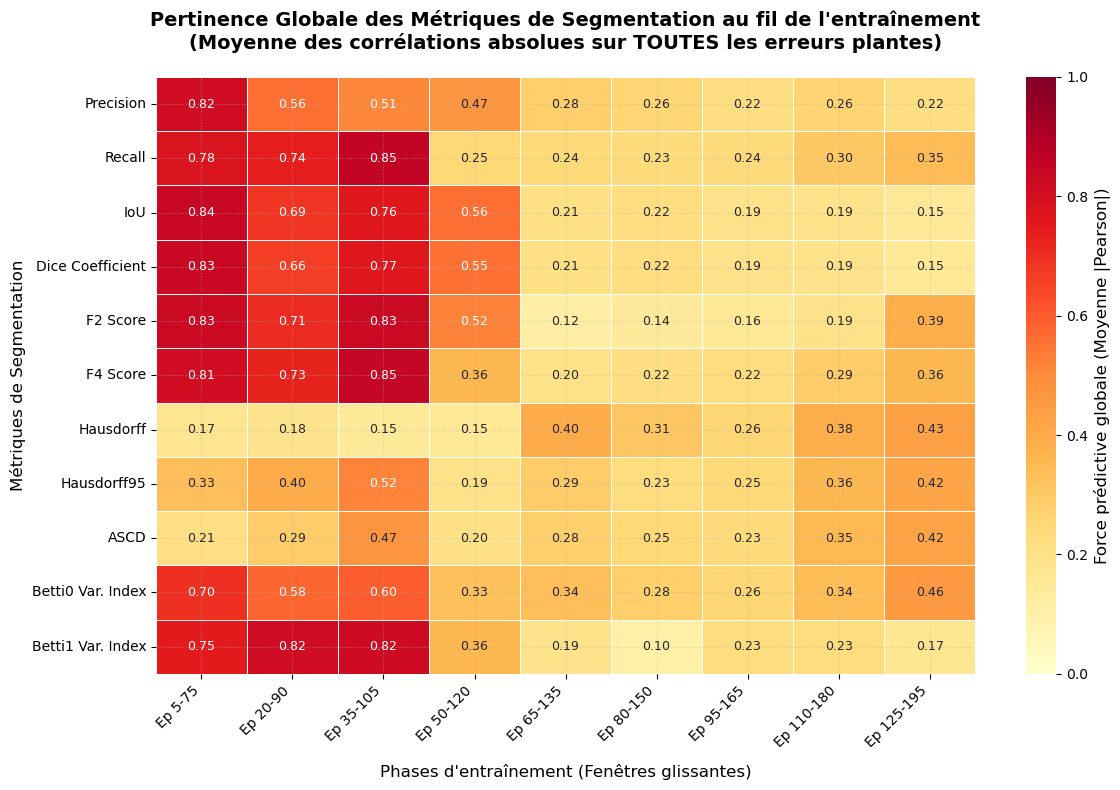

In [ ]:
# %% [markdown]
# ## Global Dynamic Rolling Correlation (All Plant Errors)

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

def plot_global_rolling_correlation(df, plant_metrics_list, img_metrics_list, window_size=10, step=2, method='spearman'):
    """
    Calcule la "force prédictive globale" de chaque métrique d'image sur TOUTES 
    les erreurs plantes confondues, en utilisant la moyenne des corrélations absolues.
    """
    # 1. Agréger par epoch
    cols_to_keep = img_metrics_list + plant_metrics_list
    df_agg = df.groupby('epoch')[cols_to_keep].mean().reset_index()
    epochs = sorted(df_agg['epoch'].dropna().unique())
    
    results = []
    window_labels = []
    
    # 2. Boucle sur les fenêtres temporelles
    for i in range(0, len(epochs) - window_size + 1, step):
        window_epochs = epochs[i : i + window_size]
        window_df = df_agg[df_agg['epoch'].isin(window_epochs)]
        
        label = f"Ep {int(window_epochs[0])}-{int(window_epochs[-1])}"
        window_labels.append(label)
        
        window_corrs = {}
        
        # Pour chaque métrique d'image...
        for img_m in img_metrics_list:
            abs_correlations = []
            
            # ... on calcule sa corrélation avec TOUTES les erreurs plantes
            for plant_m in plant_metrics_list:
                valid = window_df[[img_m, plant_m]].replace([np.inf, -np.inf], np.nan).dropna()
                
                if len(valid) >= 4:
                    if method == 'spearman':
                        corr, _ = spearmanr(valid[img_m], valid[plant_m])
                    else:
                        corr, _ = pearsonr(valid[img_m], valid[plant_m])
                    
                    if not np.isnan(corr):
                        abs_correlations.append(abs(corr)) # VALEUR ABSOLUE
            
            # La force globale de l'img_metric est la moyenne de ces corrélations absolues
            window_corrs[img_m] = np.mean(abs_correlations) if abs_correlations else np.nan
            
        results.append(window_corrs)
        
    # 3. Formatage pour Seaborn
    corr_df = pd.DataFrame(results, index=window_labels).T
    
    if 'renaming_img_dict' in globals():
        corr_df.index = [renaming_img_dict.get(m, m) for m in corr_df.index]
        
    # 4. Visualisation (Heatmap de 0 à 1)
    plt.figure(figsize=(max(12, len(window_labels) * 0.8), max(8, len(img_metrics_list) * 0.4)))
    
    # Palette séquentielle car on va de 0 (aucune corrélation) à 1 (corrélation parfaite)
    sns.heatmap(
        corr_df, 
        annot=True, 
        fmt=".2f", 
        cmap='YlOrRd',       # Jaune (faible) vers Rouge foncé (fort)
        vmin=0, vmax=1,      # Echelle de 0 à 1
        cbar_kws={'label': f'Force prédictive globale (Moyenne |{method.capitalize()}|)'},
        linewidths=0.5,
        annot_kws={"size": 9}
    )
    
    plt.title("Pertinence Globale des Métriques de Segmentation au fil de l'entraînement\n(Moyenne des corrélations absolues sur TOUTES les erreurs plantes)", 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel("Phases d'entraînement (Fenêtres glissantes)", fontsize=12, labelpad=10)
    plt.ylabel("Métriques de Segmentation", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    return corr_df

toutes_les_erreurs_plantes = plant_smape_err 

print("Génération de la matrice d'importance globale des métriques d'images...")
df_global_importance = plot_global_rolling_correlation(
    df=df_diff_log_epoch_mean, 
    plant_metrics_list=toutes_les_erreurs_plantes, 
    img_metrics_list=img_metrics, 
    window_size=15, 
    step=3, 
    method='pearson'
)